# DMD Slice Analysis

Example usage of `pyNeuroDAP.slice` for DMD patch-clamp slice electrophysiology.

**Steps covered:**
1. Scan a `Results-*` folder and load the `cells_DMD` table
2. Query a specific spot's response traces
3. Build a tidy long-format DataFrame of all spots
4. Run `analyze_dmd_search` — per-depth metrics and summary figures
5. Run `analyze_dmd_search_pair` — paired search comparison

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
import re
import pyNeuroDAP as ndap

In [19]:
def vhold_color(v):
    if v <= -50:   # ~ -70 mV
        return "tab:red"
    if v >= 0:     # ~ +10 mV
        return "tab:blue"
    return "tab:purple"  # ~ -35 mV

## Configuration

Edit `RESULTS_DIR` to point to your `Results-*` folder.

In [20]:
RESULTS_DIR = (
    # "/Users/shunli/Projects/pyNeuroDAP/Data/Patch/"
    "/Volumes/Neurobio/MICROSCOPE/Shun/Project valence/Patch/from_DC_PLOM/"
    "SL401/Results-20260214"
    # "SL404/Results-20260214"
)
SAVE_DIR = os.path.join(RESULTS_DIR, "python_output")

## 1. Load the `cells_DMD` table

In [21]:
idx = ndap.index_results_folder(RESULTS_DIR)
print(f"cells MAT : {idx['cells_mat_path']}")
print(f"cell dirs : {list(idx['cell_dirs'].keys())}")
print(f"spots files: {len(idx['spots_files'])}")

cells MAT : /Volumes/Neurobio/MICROSCOPE/Shun/Project valence/Patch/from_DC_PLOM/SL401/Results-20260214/cells_DMD_SL401.mat
cell dirs : [4, 5, 6]
spots files: 11


In [22]:
cells_df = ndap.load_cells_table(idx["cells_mat_path"])
print(f"{len(cells_df)} cells: {cells_df['Cell'].tolist()}")
for _, row in cells_df.iterrows():
    print(f"  Cell {row['Cell']}: epochs = {row['Epochs']}")
cells_df[["Cell", "Epochs", "Vhold"]]

3 cells: [4, 5, 6]
  Cell 4: epochs = ['spots_cell4_epoch5', 'spots_cell4_epoch5_hotspot_finalDepth_exci', 'spots_cell4_epoch5_hotspot_finalDepth_inhi', 'spots_cell4_epoch5_hotspot_maxSearchDepth_exci', 'spots_cell4_epoch5_hotspot_maxSearchDepth_inhi']
  Cell 5: epochs = ['spots_cell5_epoch10']
  Cell 6: epochs = ['spots_cell6_epoch5', 'spots_cell6_epoch5_hotspot_finalDepth_exci', 'spots_cell6_epoch5_hotspot_maxSearchDepth_exci', 'spots_cell6_epoch5_hotspot_maxSearchDepth_inhi']


,Cell,Epochs,Vhold
0,4,"[spots_cell4_epoch5, spots_cell4_epoch5_hotspo...","[-35.110600000000005, -70.2925, 10.00700000000..."
1,5,[spots_cell5_epoch10],[10.471250000000001]
2,6,"[spots_cell6_epoch5, spots_cell6_epoch5_hotspo...","[-35.110600000000005, -70.22749999999999, -70...."


## 2. Query a single spot's response

Retrieve all sweeps for **cell 3, search 0, depth 1, spot 0** (zero-indexed).
Use the `type` argument to return only a subset: `'traces'`, `'features'`, or `'meta'`.

In [34]:
cell = 4
depth = 5
hotspot = 0

resp = ndap.get_spot_response(
    cells_df,
    cell=cell,
    depth=depth,
    hotspot=hotspot,
    debug=False,
)

print("Meta:", resp["meta"])
print("\nTrace shapes:")
for trace_type, searches in resp["traces"].items():
    for search_key, arr in searches.items():
        if isinstance(arr, np.ndarray):
            print(f"  {trace_type}/{search_key}: {arr.shape}")

print("\nFeatures:", {k: v for k, v in resp["features"].items() if not isinstance(v, dict)})

Meta: {'cell': 4, 'depth': 5, 'hotspot_selector': 0, 'output_fs': 10000.0, 'time_range_ms': [-20.0, 100.0], 'spot_index': {'search_0': 2, 'search_3': 3, 'search_4': 3}, 'spot_box': {'search_0': [39.0, 57.0, 1.0, 21.0], 'search_3': [58.0, 76.0, 1.0, 21.0], 'search_4': [58.0, 76.0, 1.0, 21.0]}, 'spot_loc': {'search_0': [0, 2], 'search_3': [0, 3], 'search_4': [0, 3]}, 'spot_rc': {'search_0': [0, 2], 'search_3': [0, 3], 'search_4': [0, 3]}, 'event_sample': 201}

Trace shapes:
  opto/search_0: (5, 1201)
  opto/search_3: (20, 1201)
  opto/search_4: (20, 1201)
  baseline/search_0: (5, 301)
  baseline/search_3: (20, 301)
  baseline/search_4: (20, 301)
  hotspot/search_0: (5,)
  hotspot/search_3: (20,)
  hotspot/search_4: (20,)

Features: {'Ethres': -17.809331117604778, 'Ithres': 17.809331117604778}


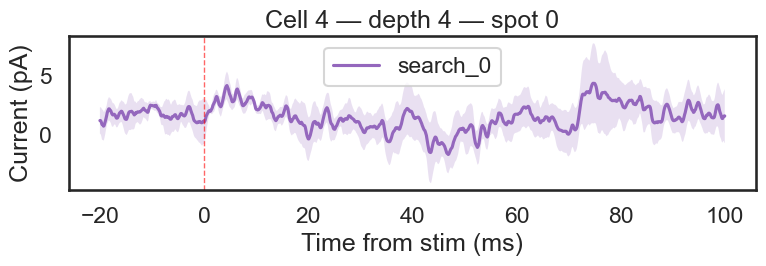

In [33]:
# Quick plot of the spot's opto trace(s)
opto = resp["traces"]["opto"]  # (n_sweeps, n_samples)
output_fs = resp["meta"]["output_fs"]
t_ms = (np.arange(1201) - resp["meta"]["event_sample"] + 1) / (output_fs / 1000)

vholds = np.asarray(cells_df.loc[cells_df["Cell"] == cell, "Vhold"].iloc[0], float)

fig, ax = plt.subplots(figsize=(8, 3))
for key, trace in opto.items():
    si = int(re.search(r"\d+", key).group())
    v = vholds[si]
    ndap.plot_sem(trace, t_ms, plot_individual=False, ax=ax, color=vhold_color(v),
                  label=f"{key}")
ax.axvline(0, c="red", ls="--", lw=1, alpha=0.6)
ax.set(xlabel="Time from stim (ms)", ylabel="Current (pA)",
       title=f"Cell {cell} — depth {depth} — spot {hotspot}")
ax.legend()
plt.tight_layout()
plt.show()

### Plot all hotspot response for maxSearchDepth or finalDepth

In [30]:
cell = 4
depth = 5

vholds = np.asarray(cells_df.loc[cells_df["Cell"] == cell, "Vhold"].iloc[0], float)

# collect recorded hotspots (k-th recorded spot) until get_spot_response fails
hotspots = []
k = 0
while True:
    try:
        resp = ndap.get_spot_response(cells_df, cell=cell, depth=depth, hotspot=k, debug=False)
        opto = resp.get("traces", {}).get("opto", {})
        if opto:  # only keep if it actually has traces
            hotspots.append((k, resp, opto))
        k += 1
    except (IndexError, ValueError):
        break

if not hotspots:
    raise RuntimeError(f"No recorded hotspots found for cell={cell}, depth={depth}")

output_fs = hotspots[0][1]["meta"]["output_fs"]
t_ms = (np.arange(1201) - hotspots[0][1]["meta"]["event_sample"] + 1) / (output_fs / 1000)

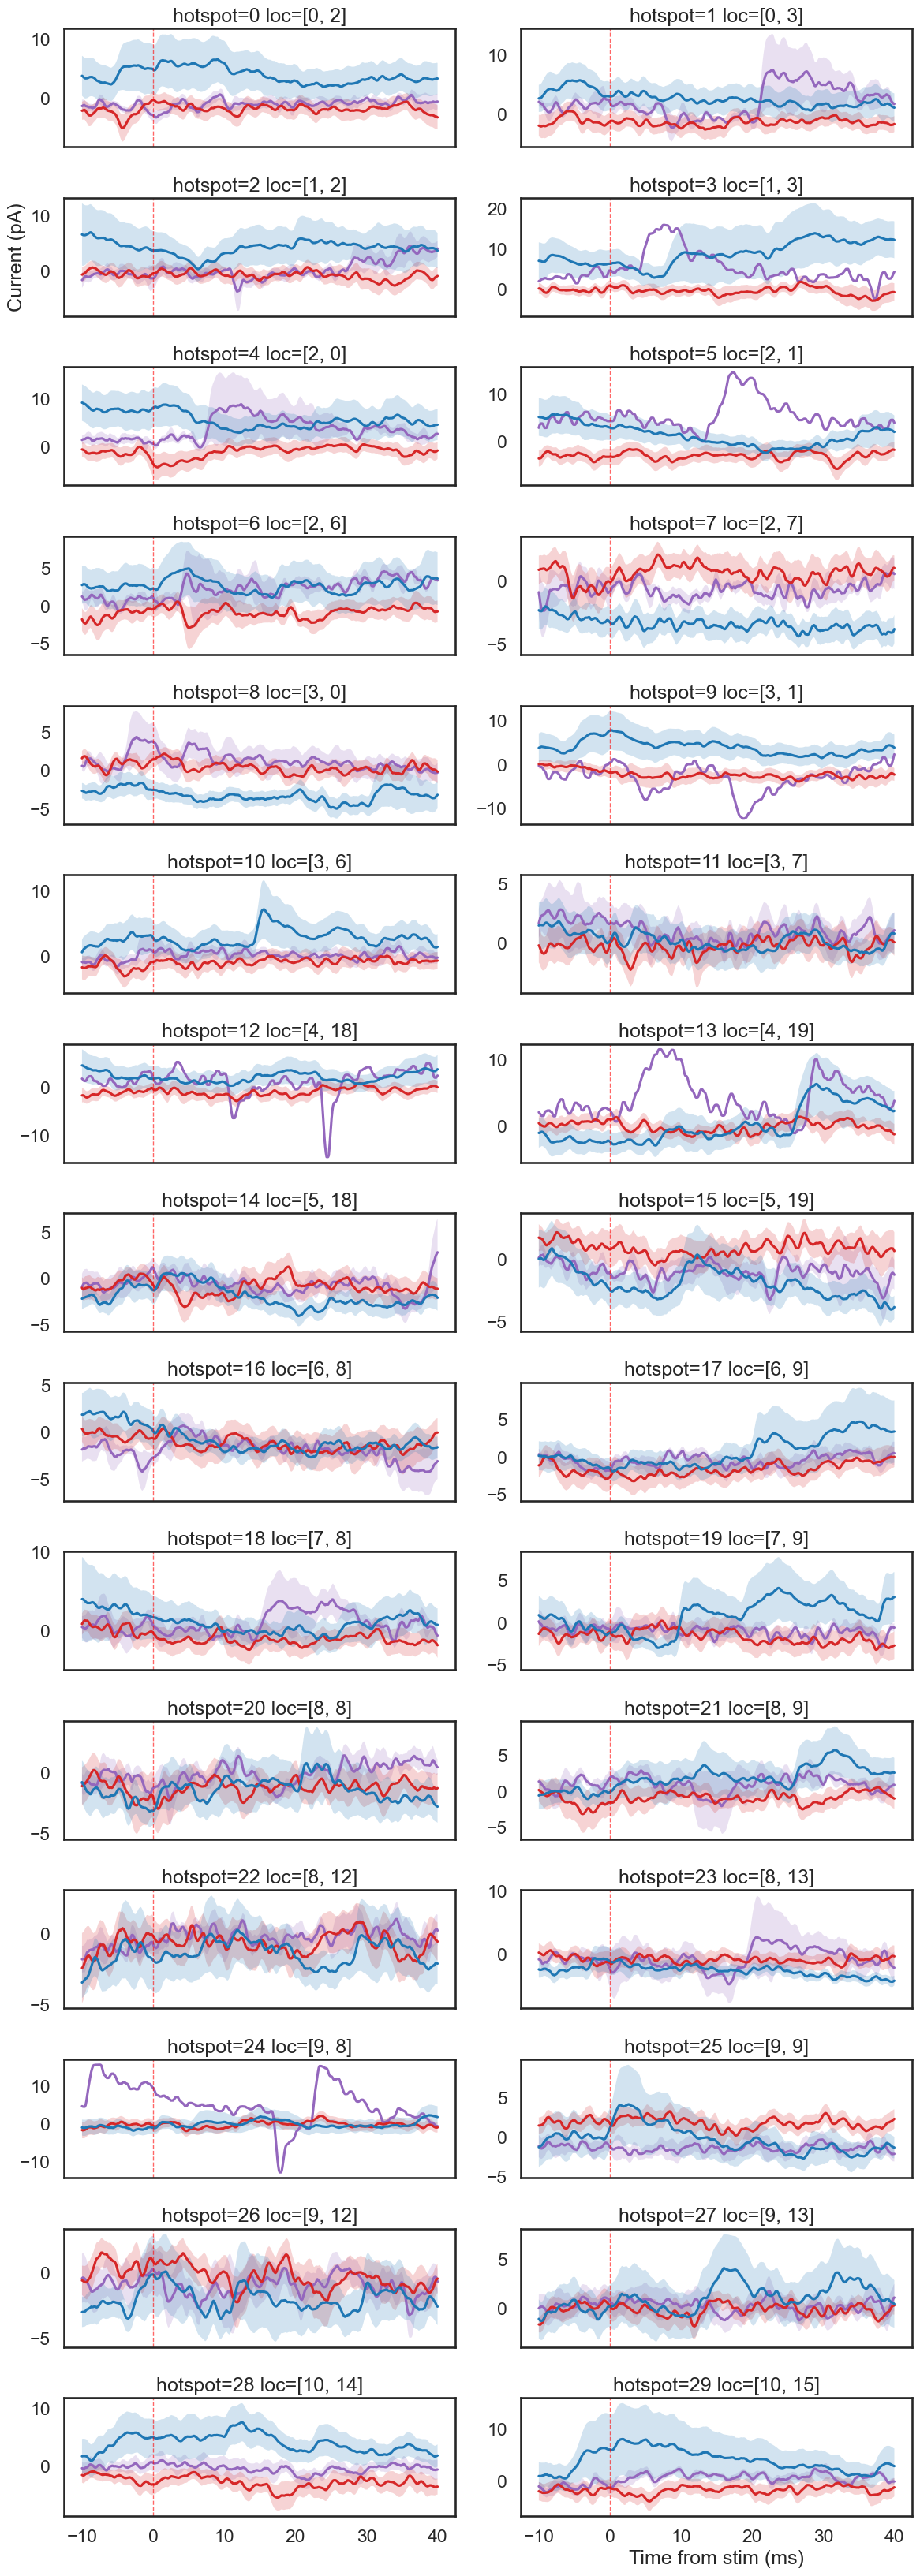

In [31]:
# --- plot window: -10 to +40 ms ---
t0, t1 = -10, 40
mask = (t_ms >= t0) & (t_ms <= t1)

n = len(hotspots)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 2.2 * nrows), sharex=True, sharey=False)
axes = np.atleast_1d(axes).ravel()
for ax, (k, resp, opto) in zip(axes, hotspots):
    for key, trace in opto.items():
        si = int(re.search(r"\d+", key).group())
        v = vholds[si]
        ndap.plot_sem(trace[:, mask], t_ms[mask], plot_individual=False, ax=ax, color=vhold_color(v))
    first_search = next(iter(opto.keys()))
    spot_loc = resp["meta"].get("spot_loc", {}).get(first_search, None)
    ax.axvline(0, c="red", ls="--", lw=1, alpha=0.6)
    ax.set_title(f"hotspot={k} loc={spot_loc}")
# turn off any unused axes
for ax in axes[len(hotspots):]:
    ax.axis("off")
axes[min(len(hotspots) - 1, len(axes) - 1)].set_xlabel("Time from stim (ms)")
axes[ncols].set_ylabel("Current (pA)") if nrows > 1 else axes[0].set_ylabel("Current (pA)")
plt.tight_layout()
plt.show()

## 3. Tidy long-format DataFrame of all spots

In [7]:
# long_df = ndap.results_to_long_dataframe(cells_df)
# print(f"Shape: {long_df.shape}")
# long_df.head(8)

# Hotspot distribution across all cells / searches / depths
# print(long_df.groupby(["cell", "depth"])["is_hotspot"].sum().unstack("depth").to_string())

## 4. Analyze a single search — `analyze_dmd_search`

Produces one summary figure per depth with:
- Tiled per-spot trace grid (hotspots highlighted)
- Response map image
- Opto vs. baseline trace overlay
- AUC and response-rate scatter-bar plots

/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out

Depths analysed: 5
  depth 1: 2/4 hotspots
  depth 2: 5/8 hotspots
  depth 3: 2/16 hotspots
  depth 4: 1/8 hotspots
  depth 5: 0/4 hotspots


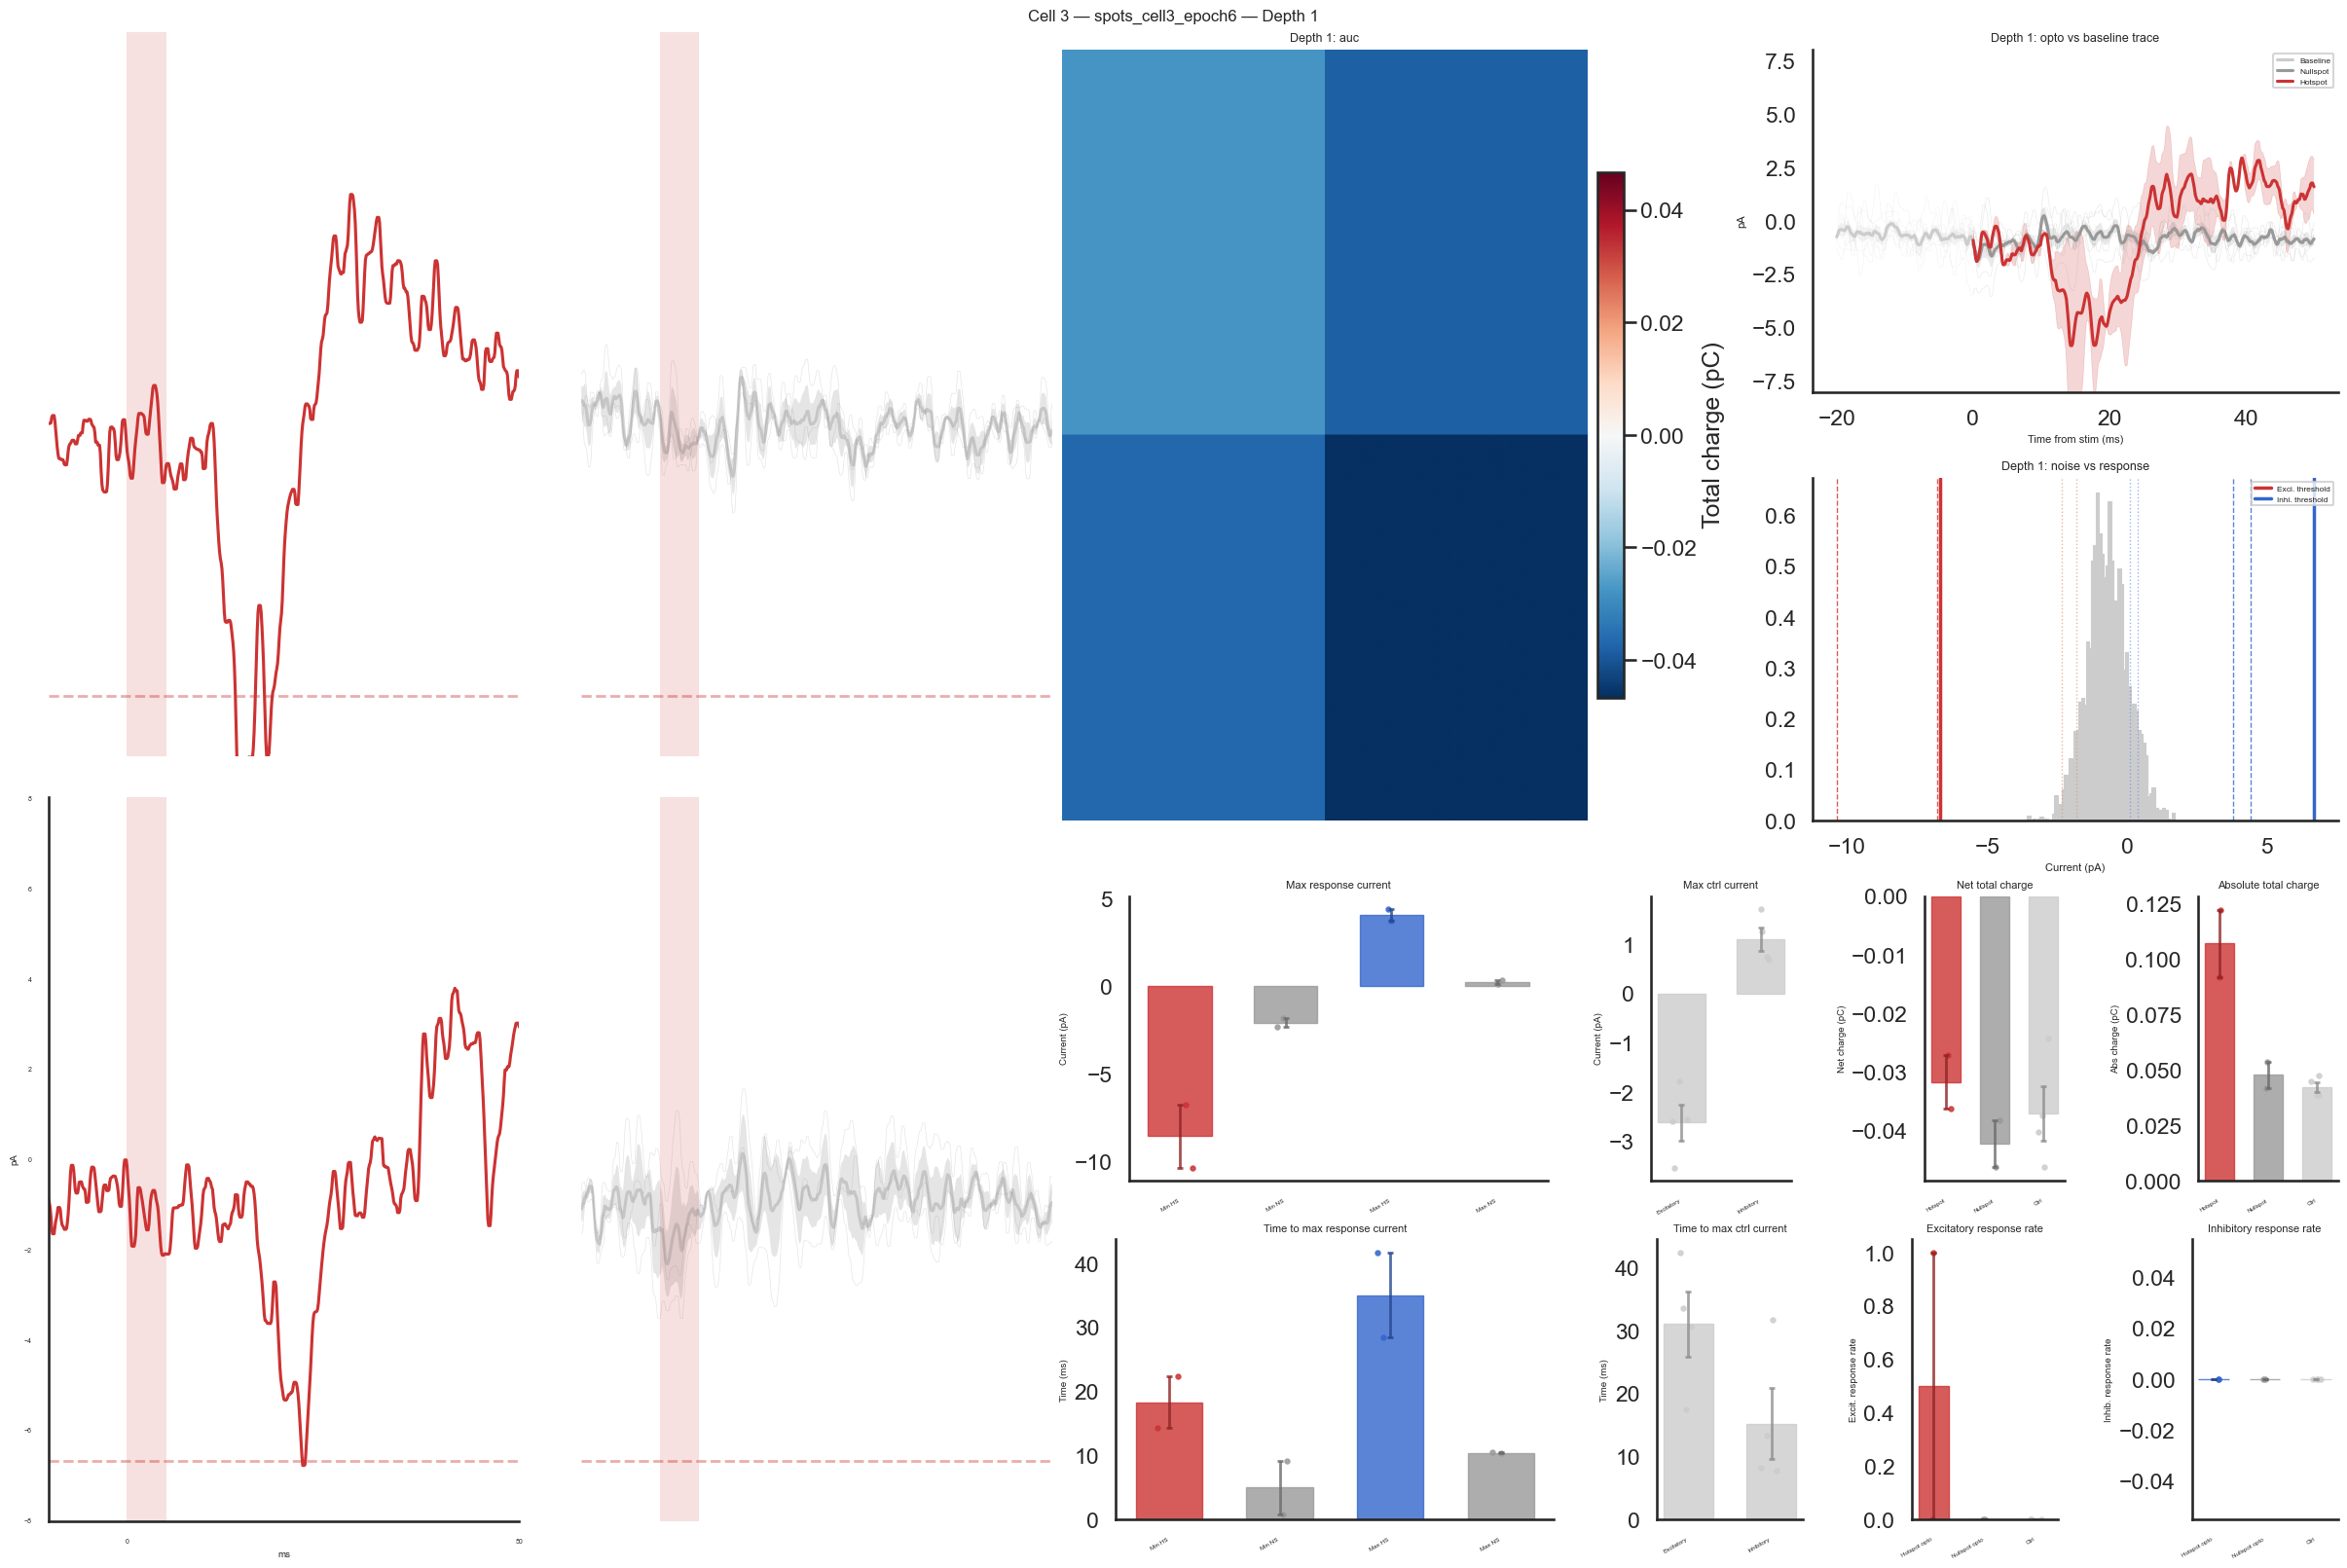

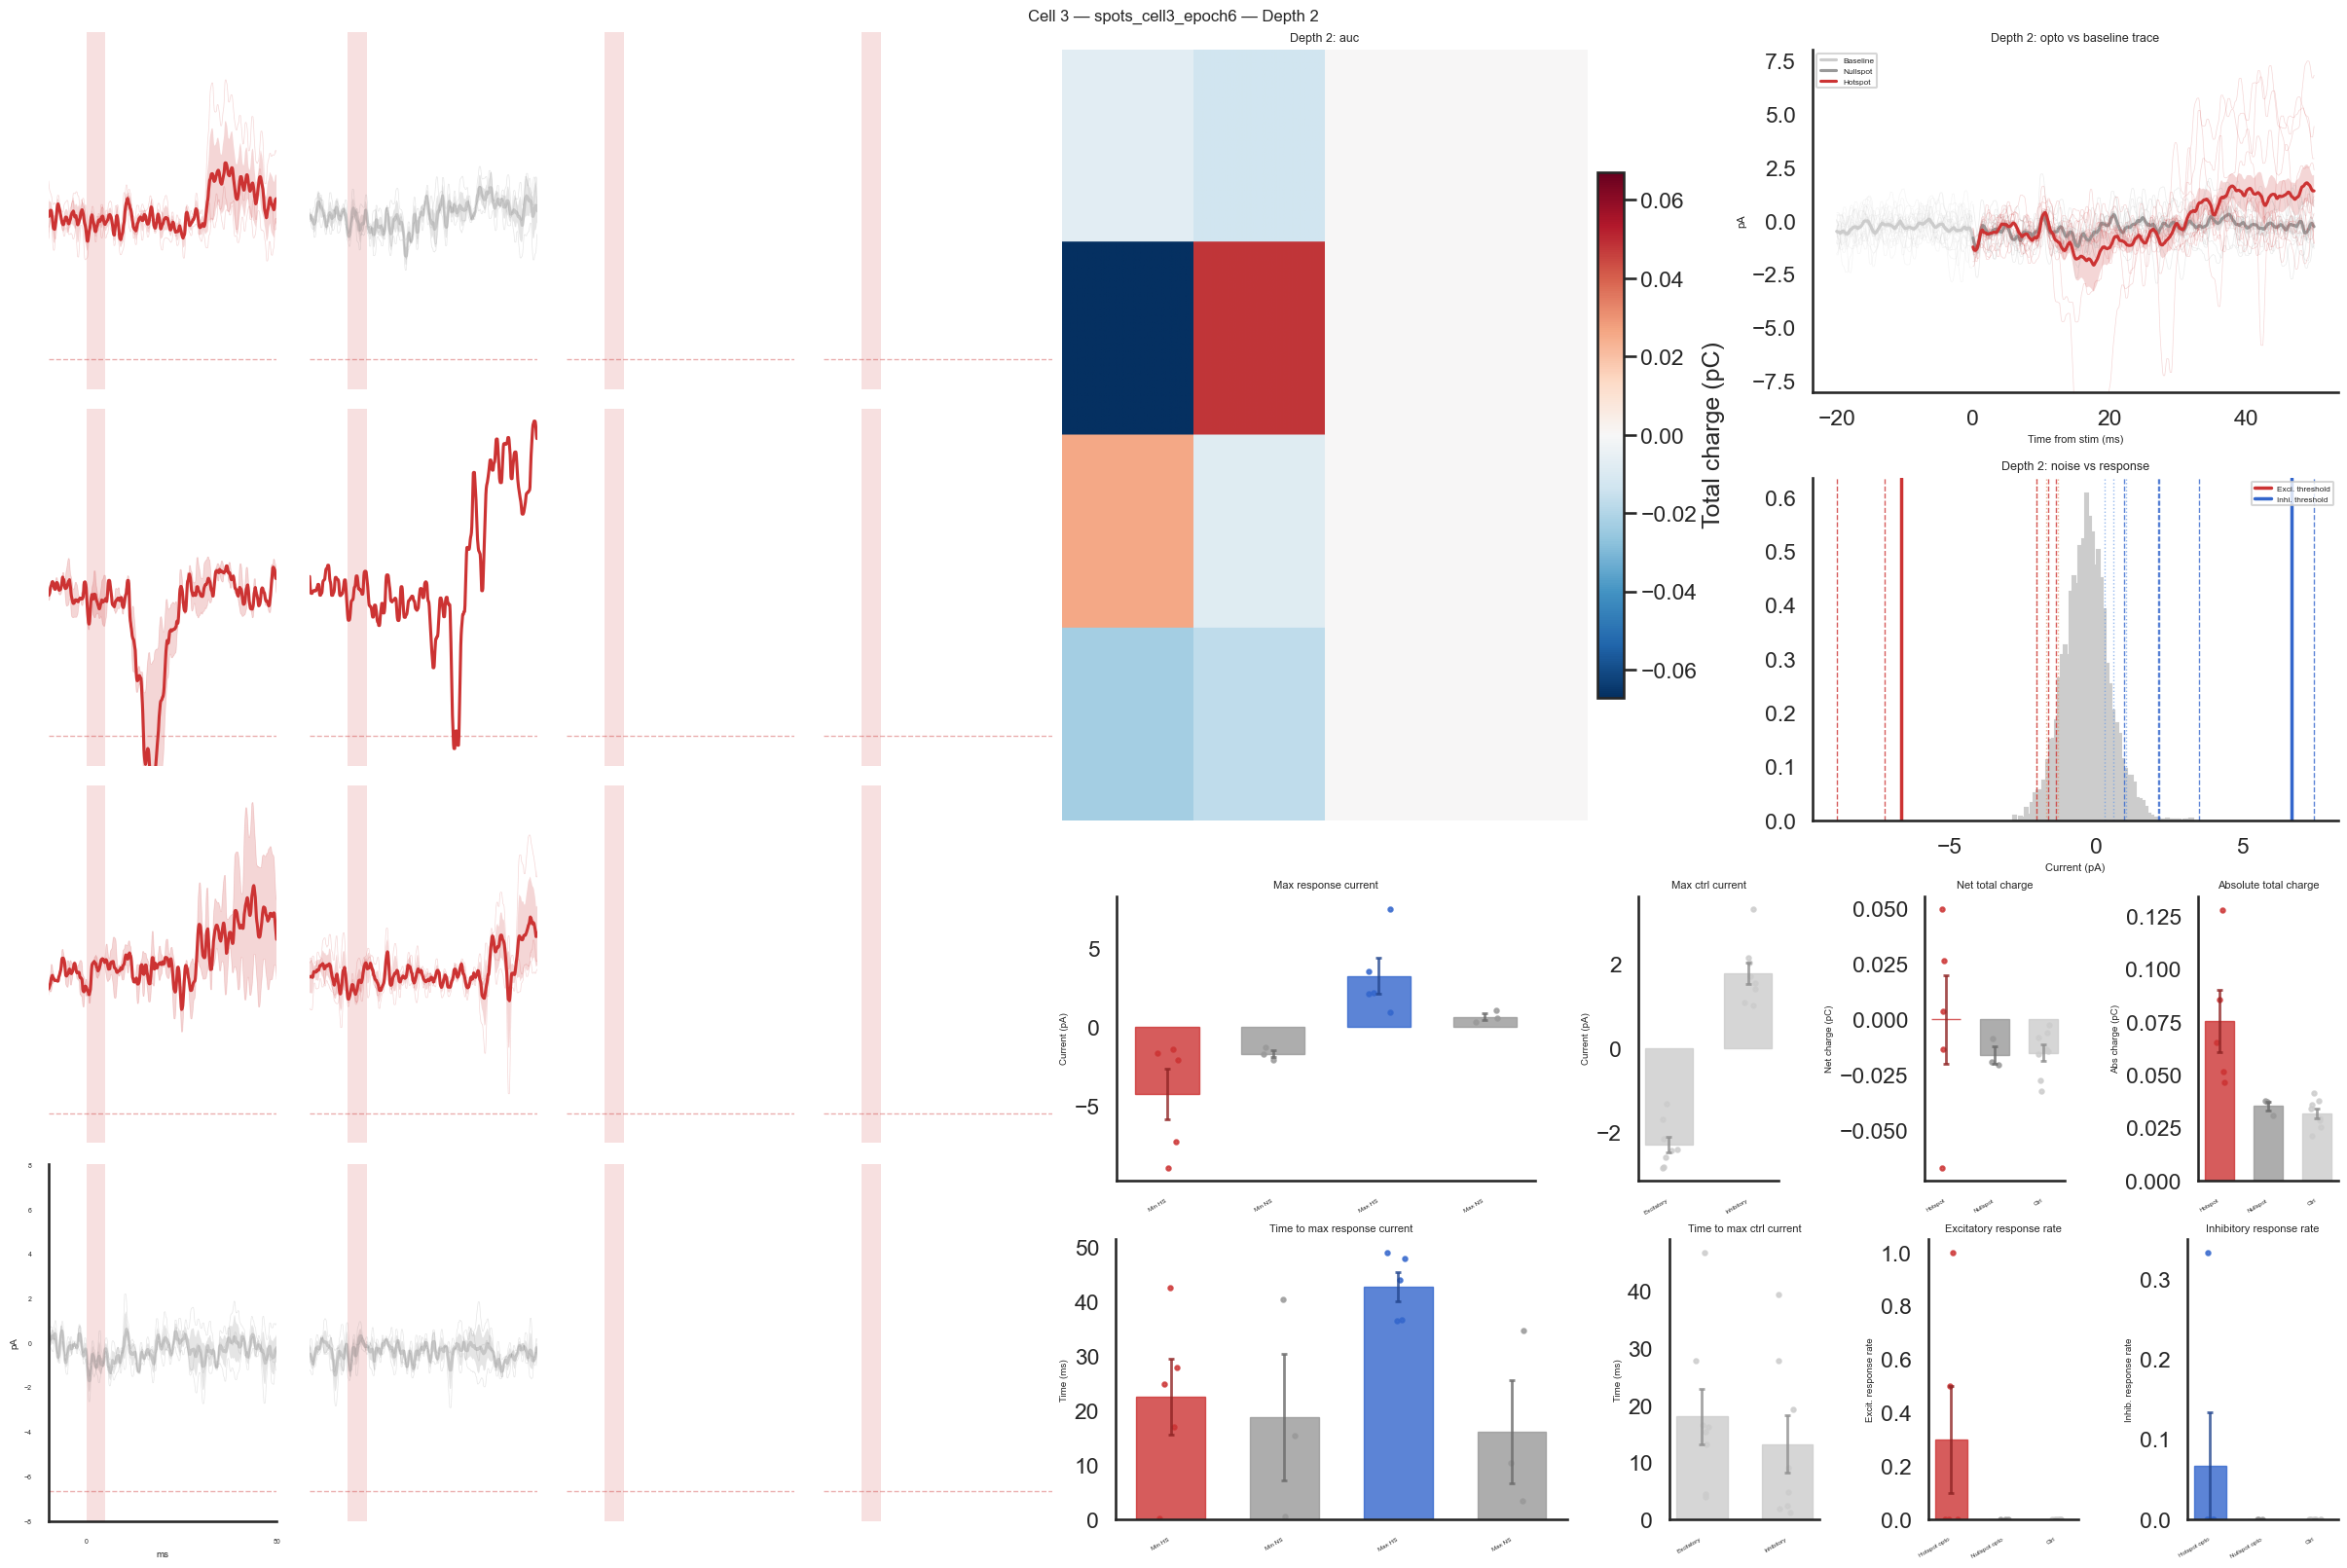

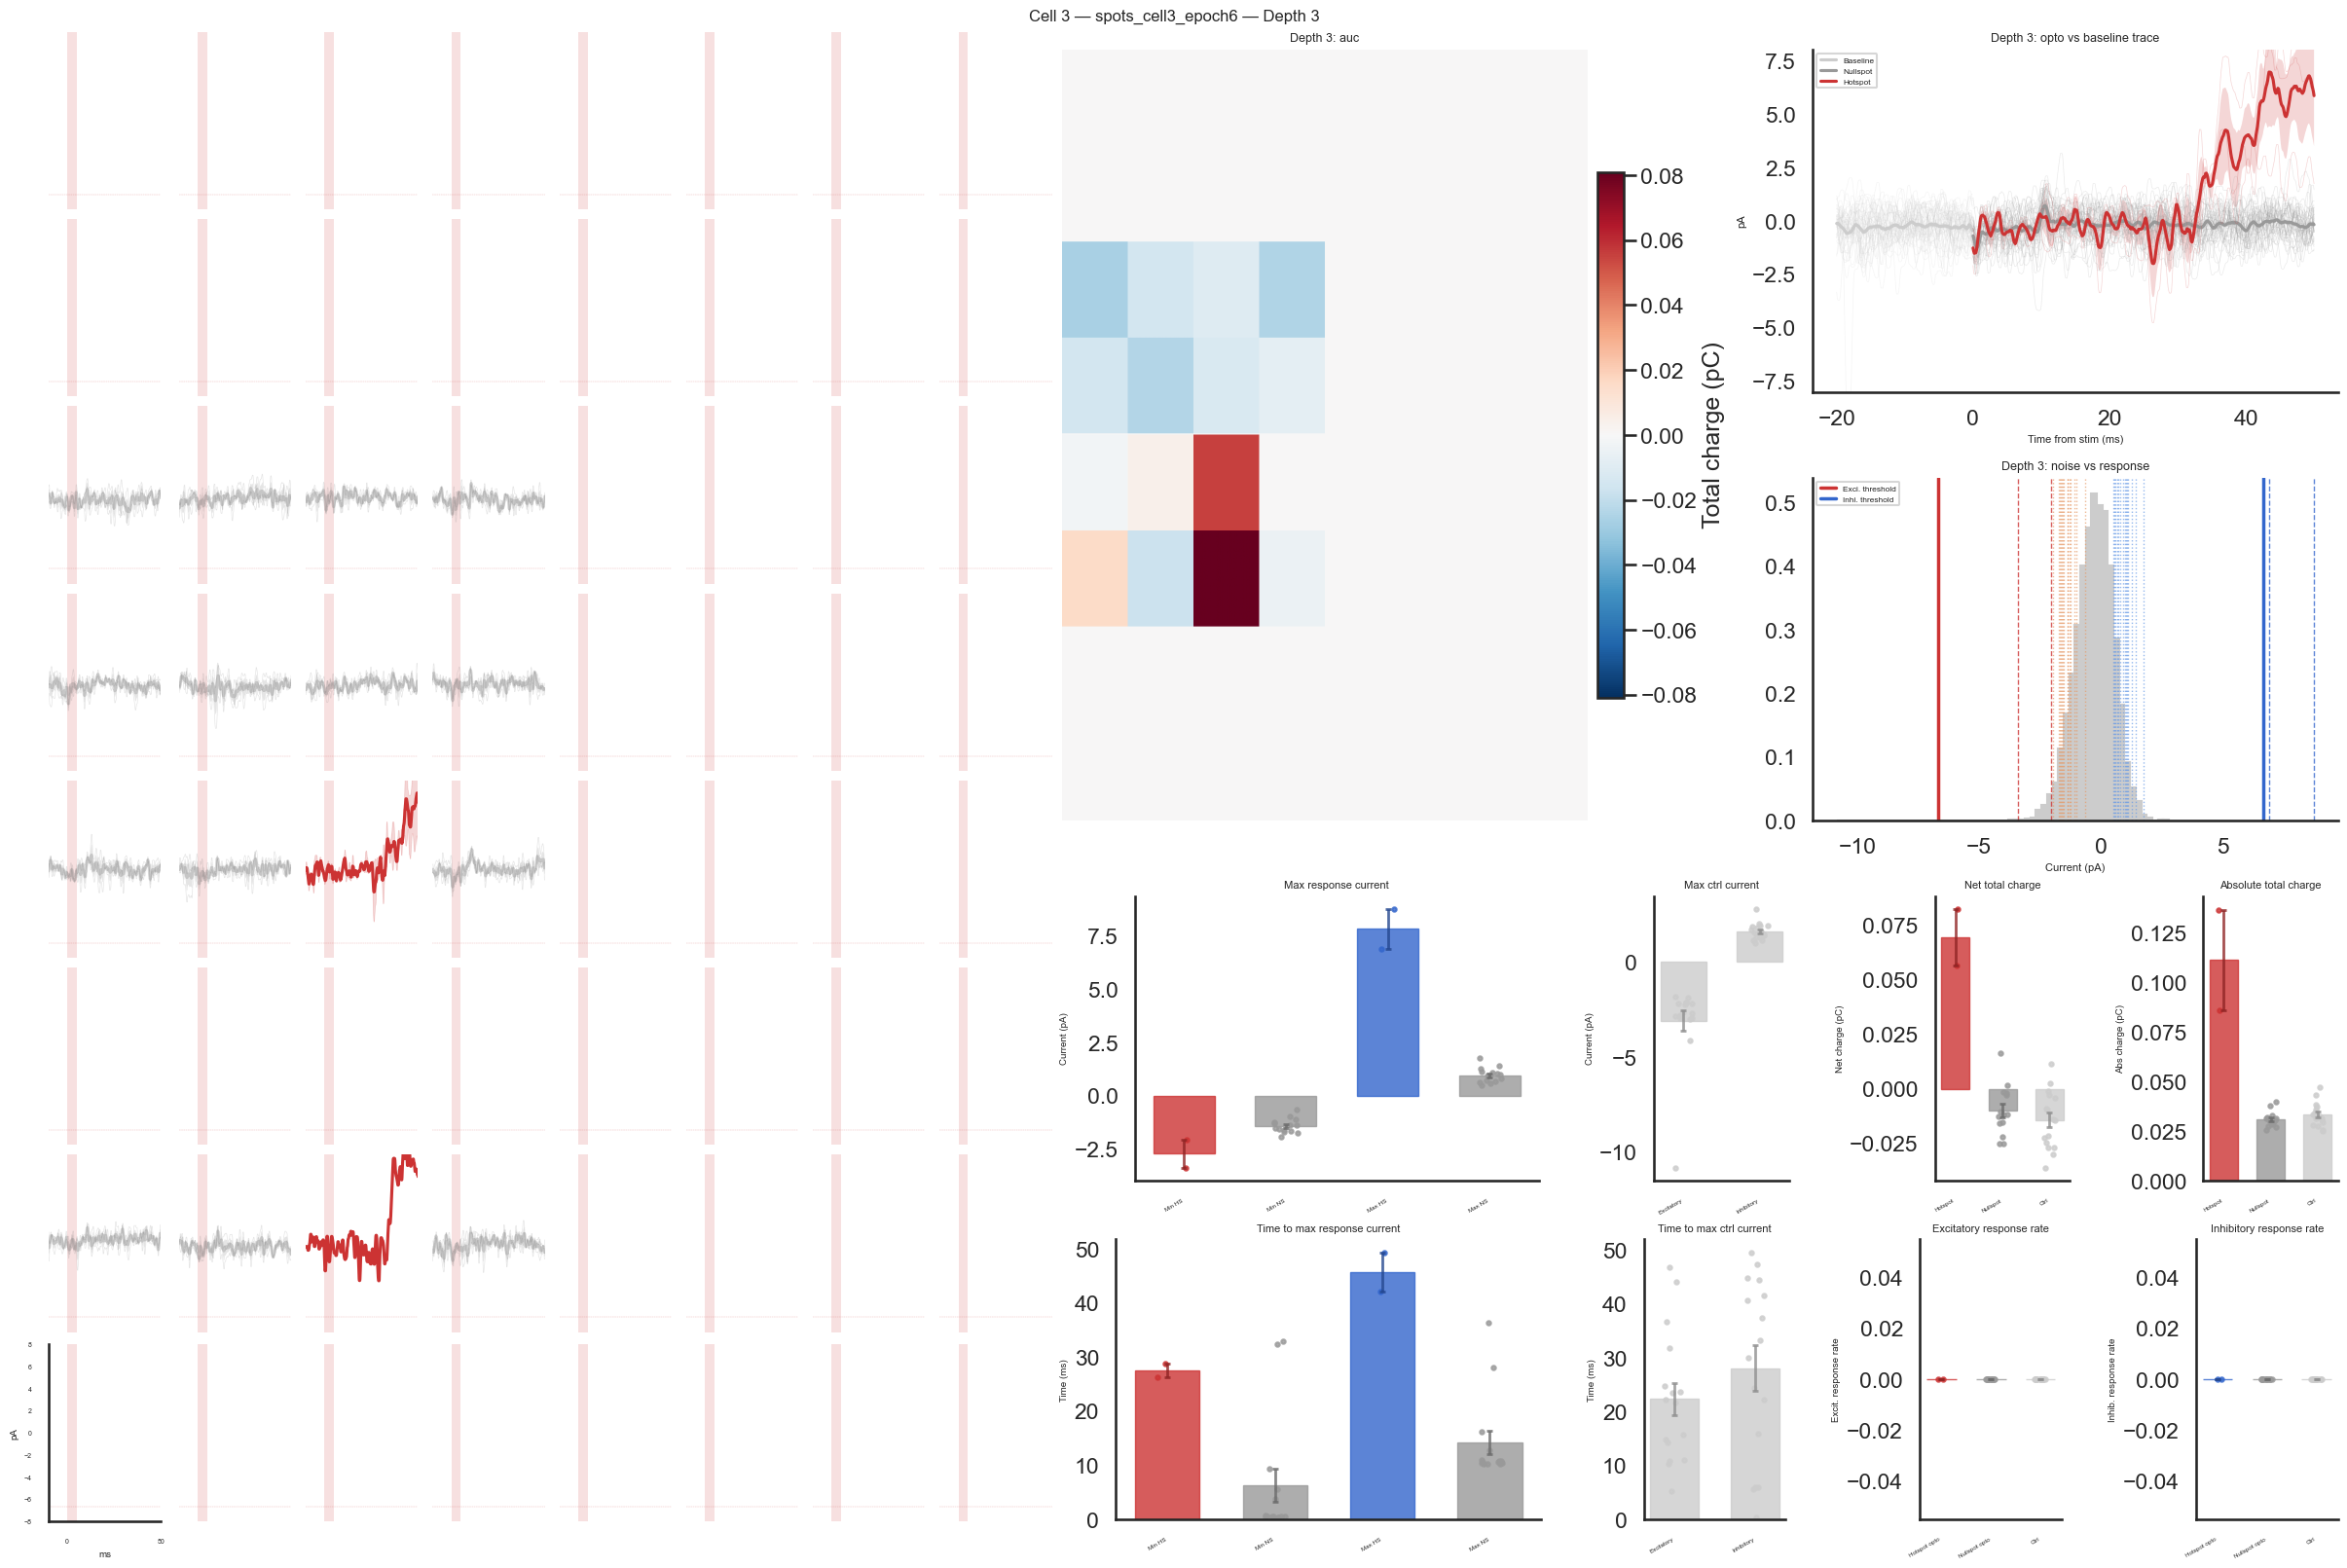

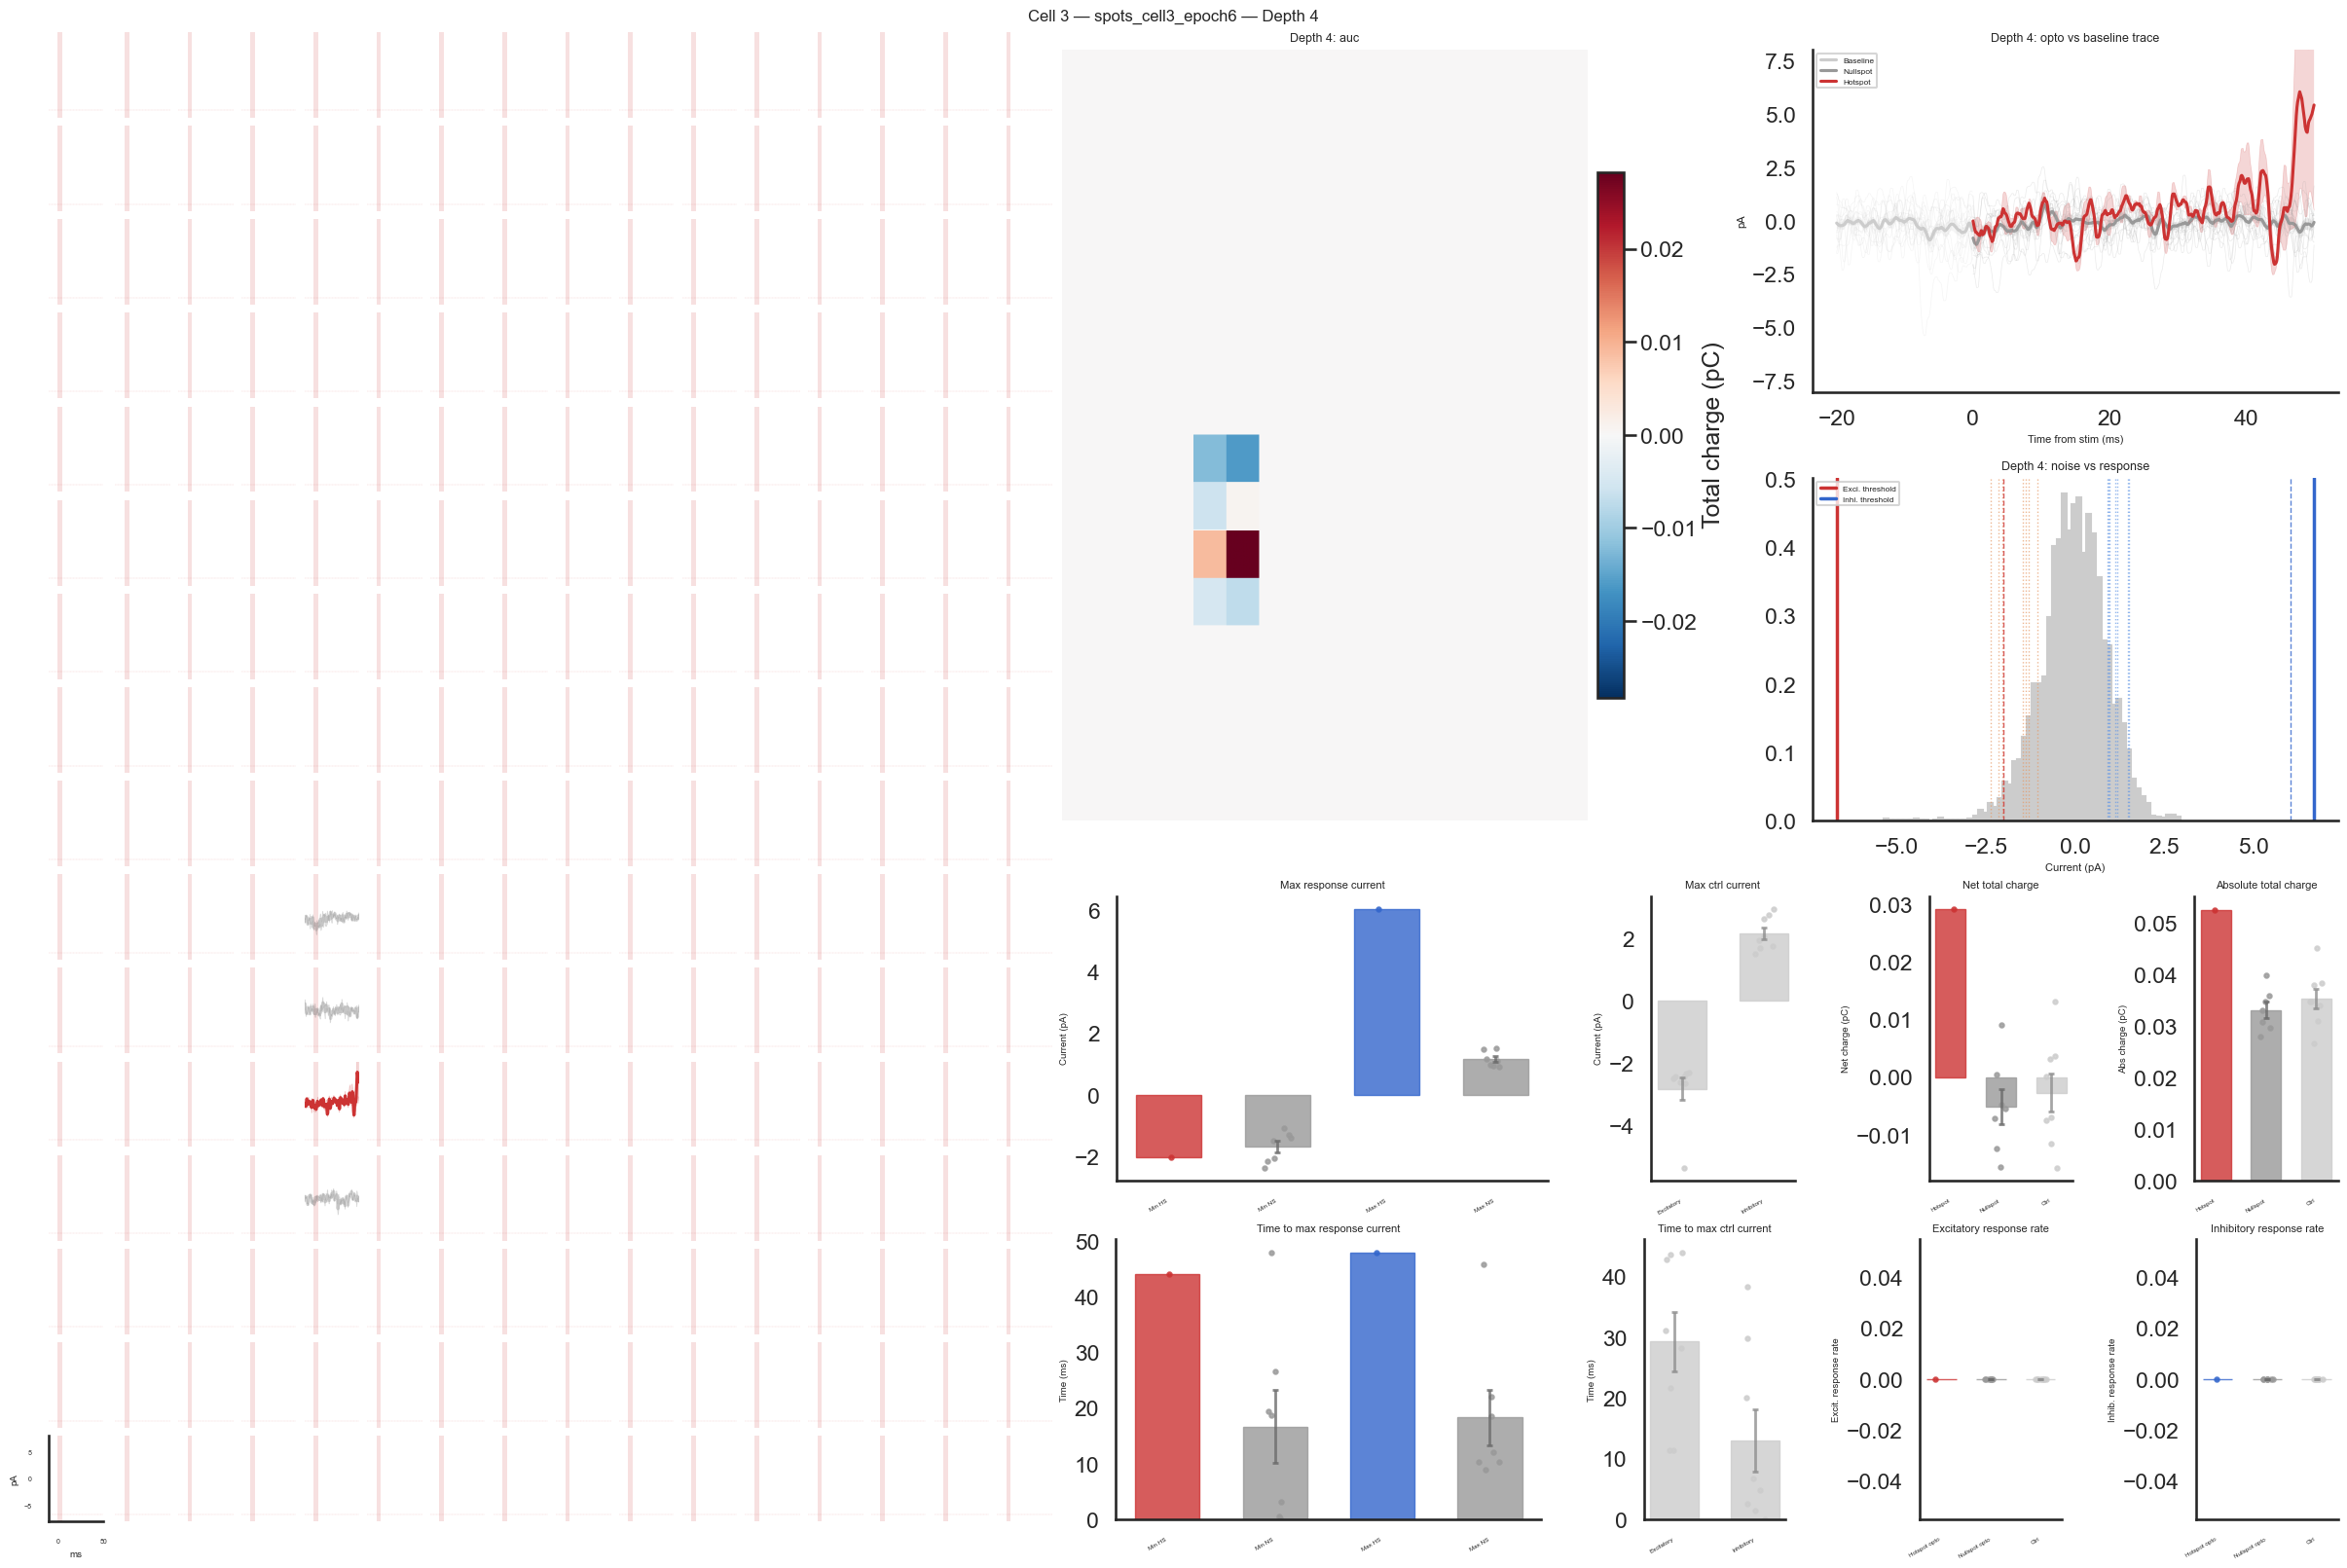

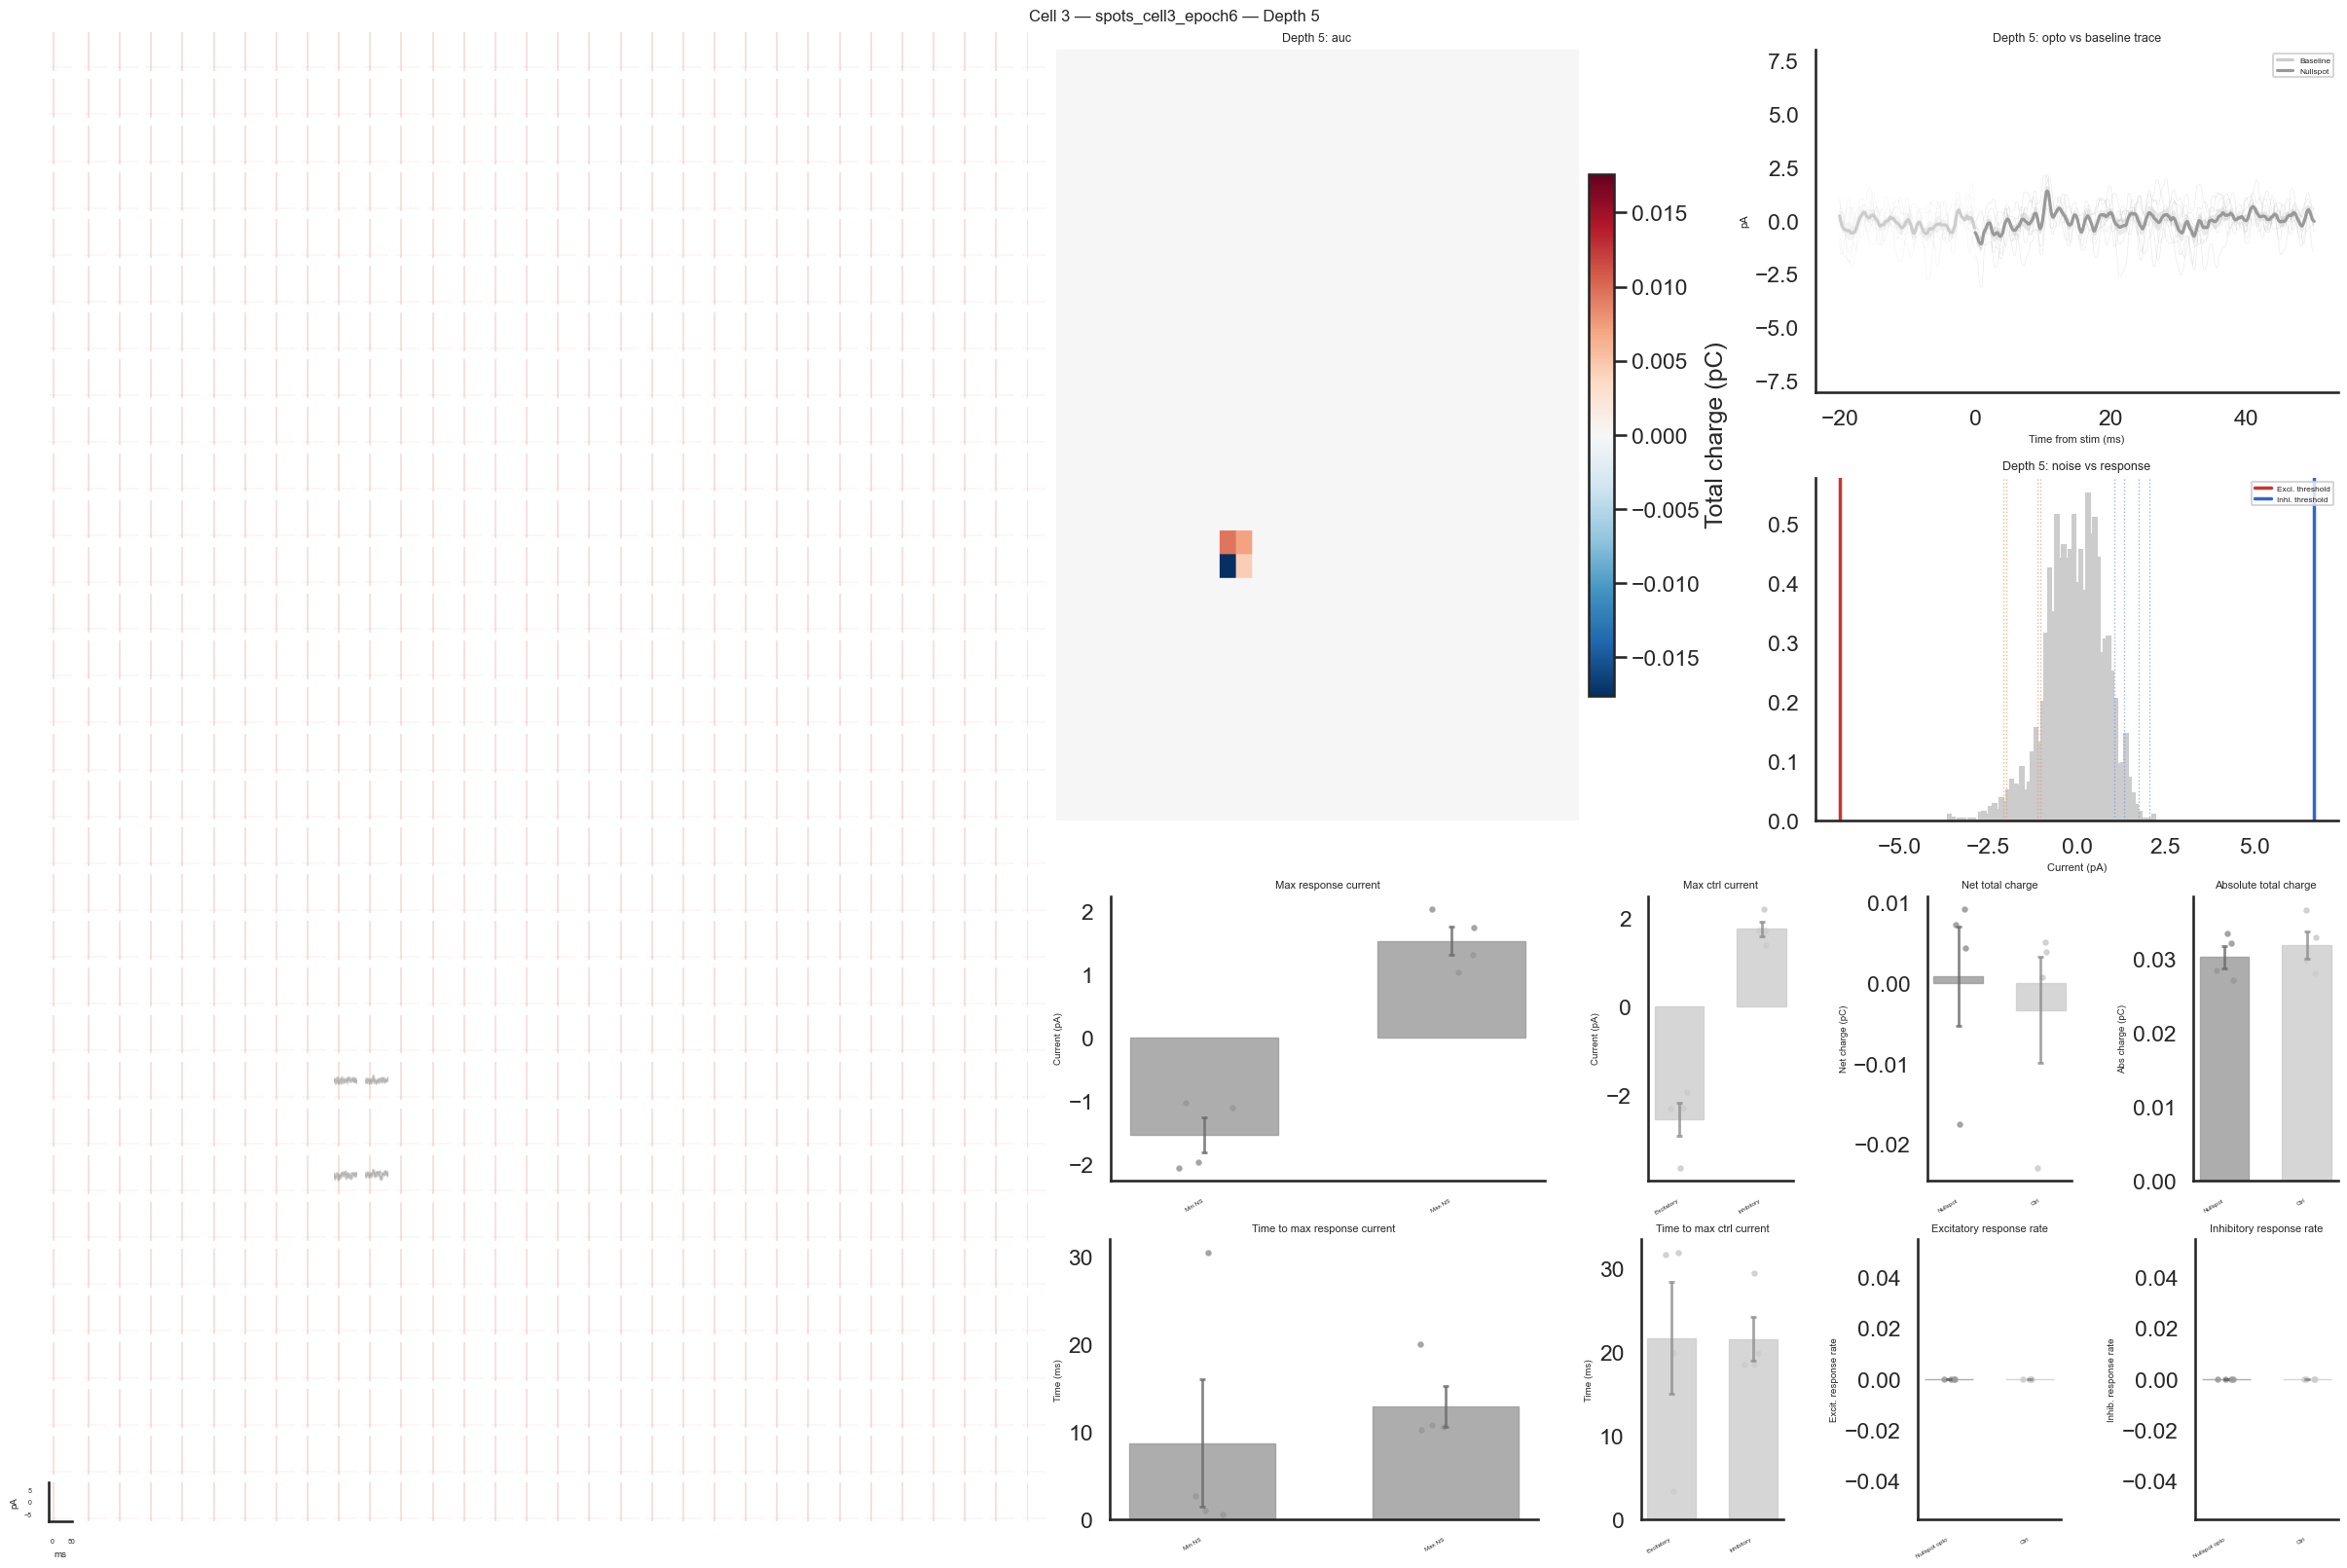

In [8]:
search_result = ndap.analyze_dmd_search(
    cells_df,
    cell=3,
    search_idx=0,
    make_plots=True,
    save_dir=SAVE_DIR,
)

print(f"Depths analysed: {len(search_result['depth_results'])}")
for dr in search_result["depth_results"]:
    n_hs = dr["hotspot_spot_idx"].sum()
    n_tot = len(dr["hotspot_spot_idx"])
    print(f"  depth {dr['depth']}: {n_hs}/{n_tot} hotspots")

In [9]:
# Per-depth metrics summary
metrics = search_result["metrics_df"]
metrics.groupby("depth")[["auc", "ctrl_auc", "e_rate", "i_rate"]].mean().round(4)

,auc,ctrl_auc,e_rate,i_rate
depth,,,,
1,-0.0369,-0.0370,0.2500,0.0000
2,-0.0061,-0.0151,0.1875,0.0417
3,-0.0000,-0.0144,0.0000,0.0000
4,-0.0008,-0.0027,0.0000,0.0000
5,0.0009,-0.0033,0.0000,0.0000


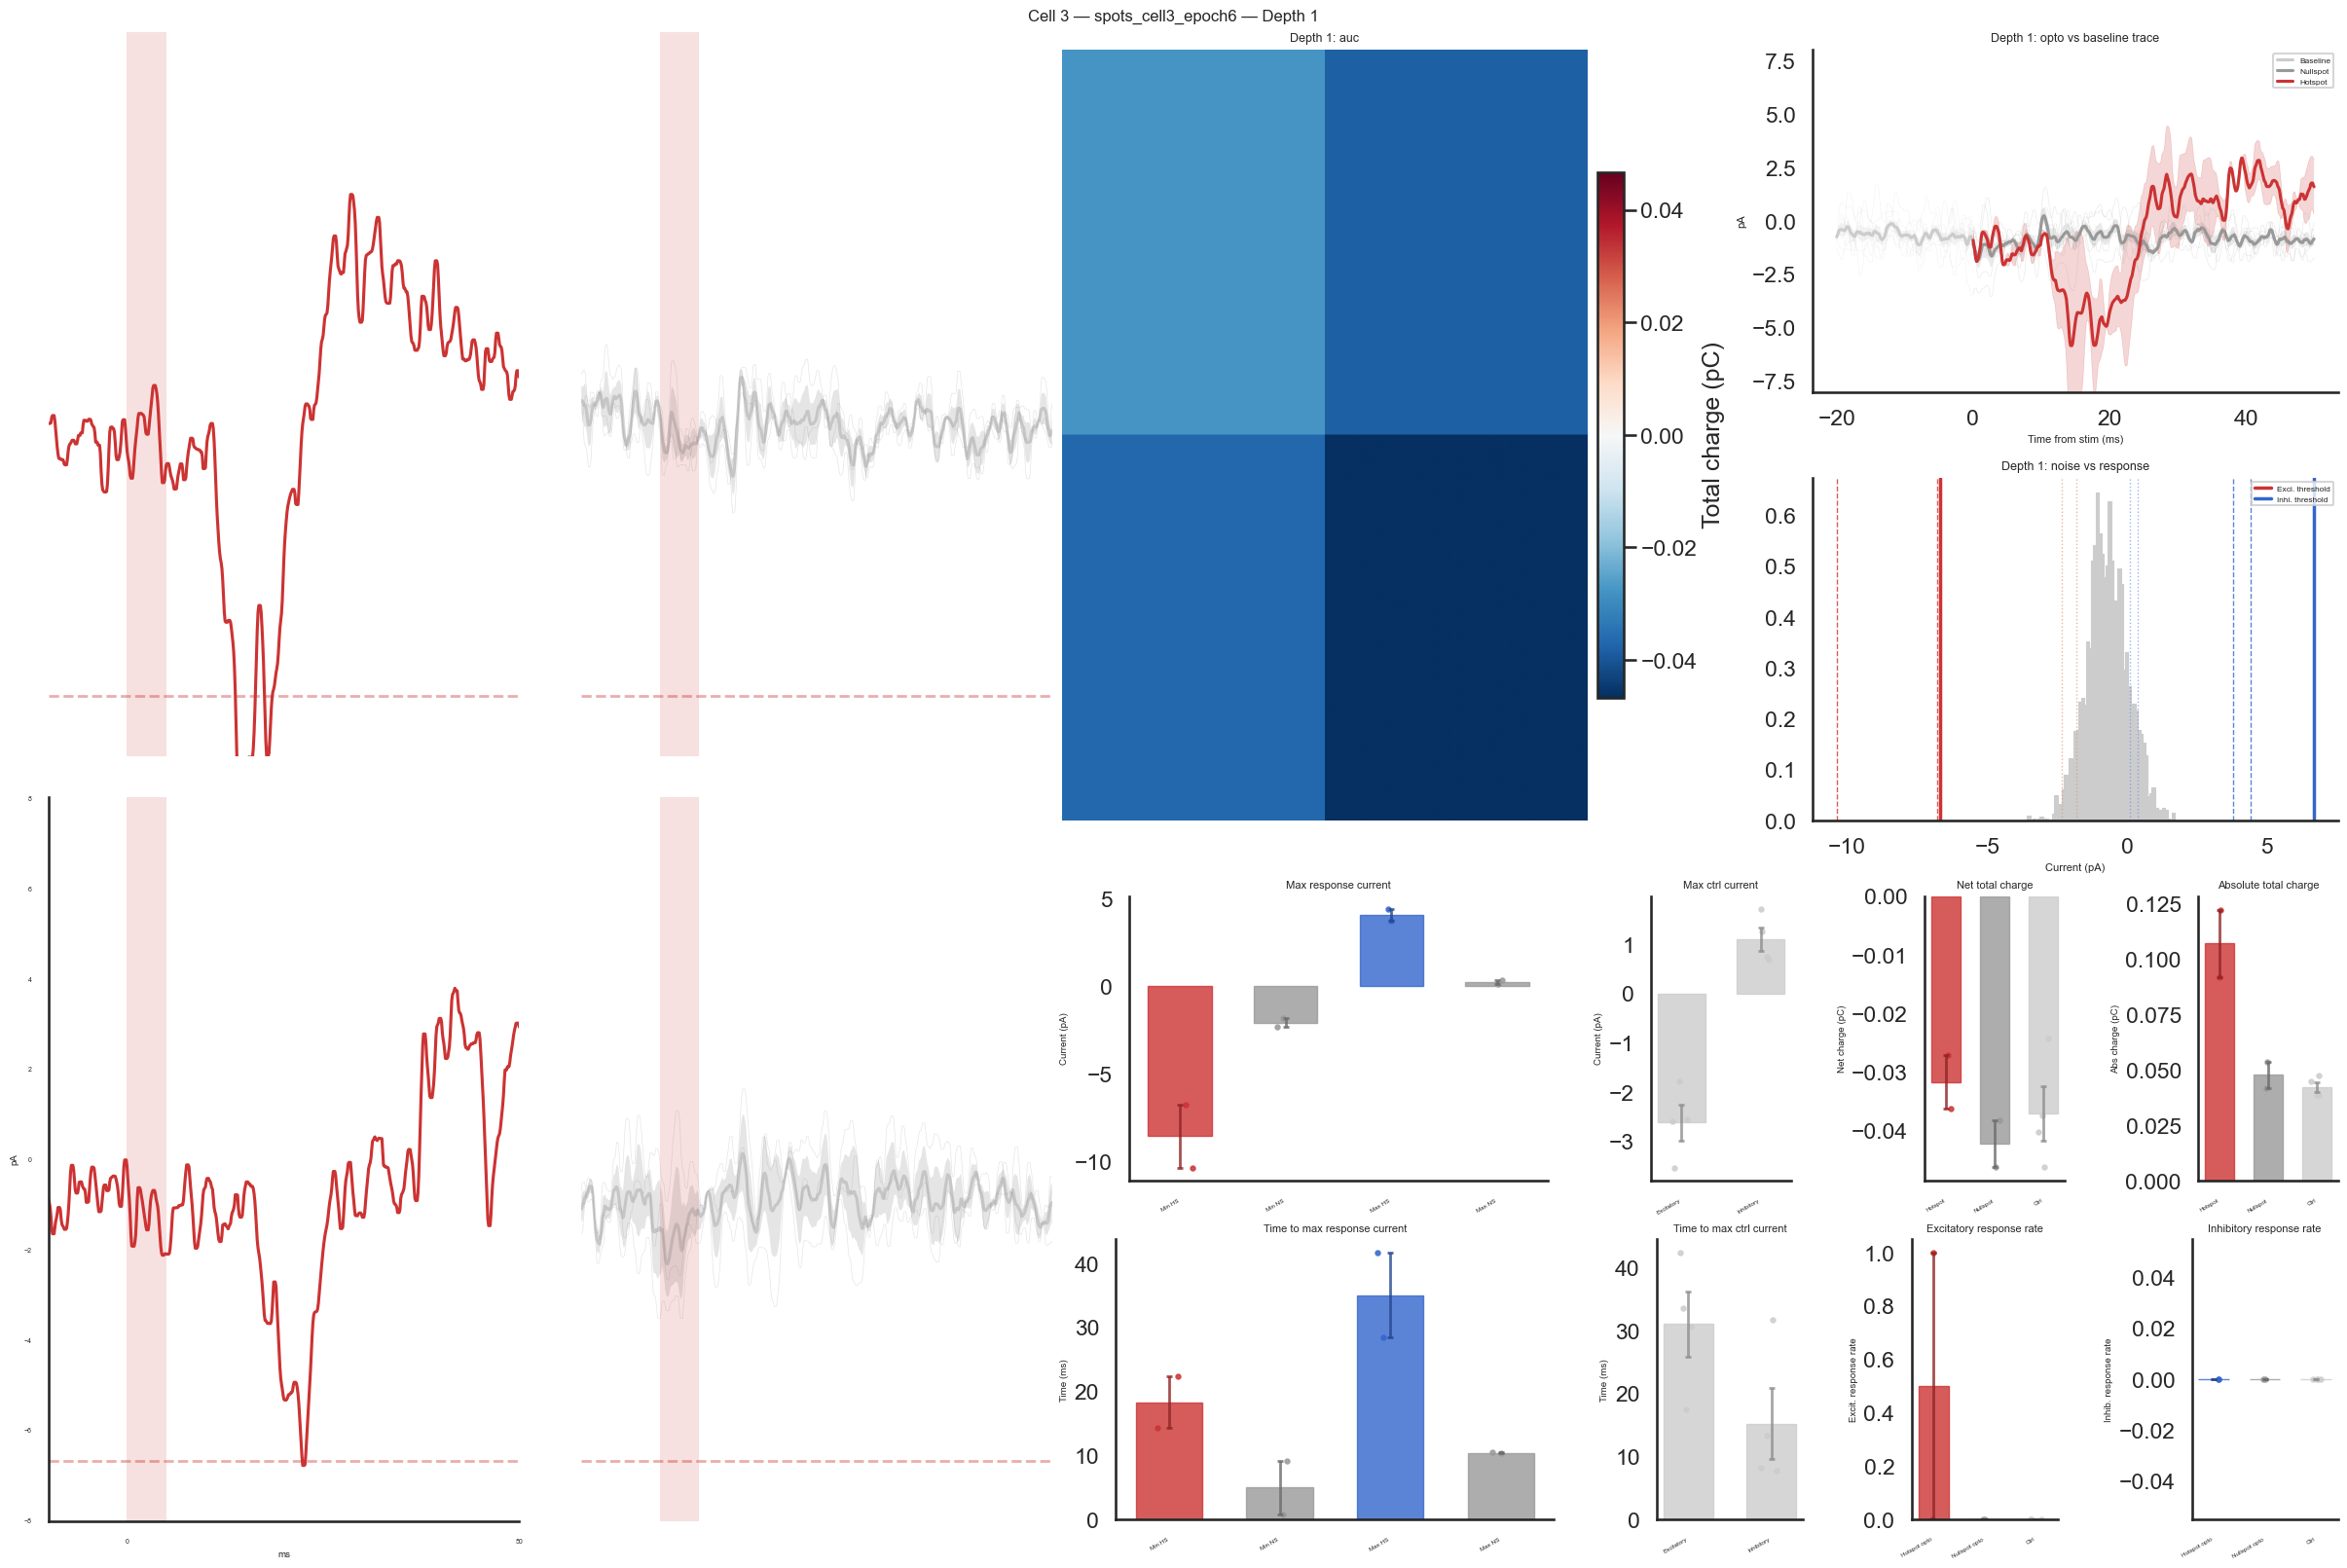

In [10]:
# Display the figure for depth 1
search_result["figures"][0]

## 5. Paired search comparison — `analyze_dmd_search_pair`

Cell 2 has two searches (`epoch8` and `epoch9`), which form one pair.
This computes per-common-depth AUC differences and comparison figures.

/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out

Common depths compared: 3
  depth 1: opto1=(9, 501), opto2=(10, 501)
  depth 2: opto1=(33, 501), opto2=(30, 501)
  depth 3: opto1=(24, 501), opto2=(36, 501)


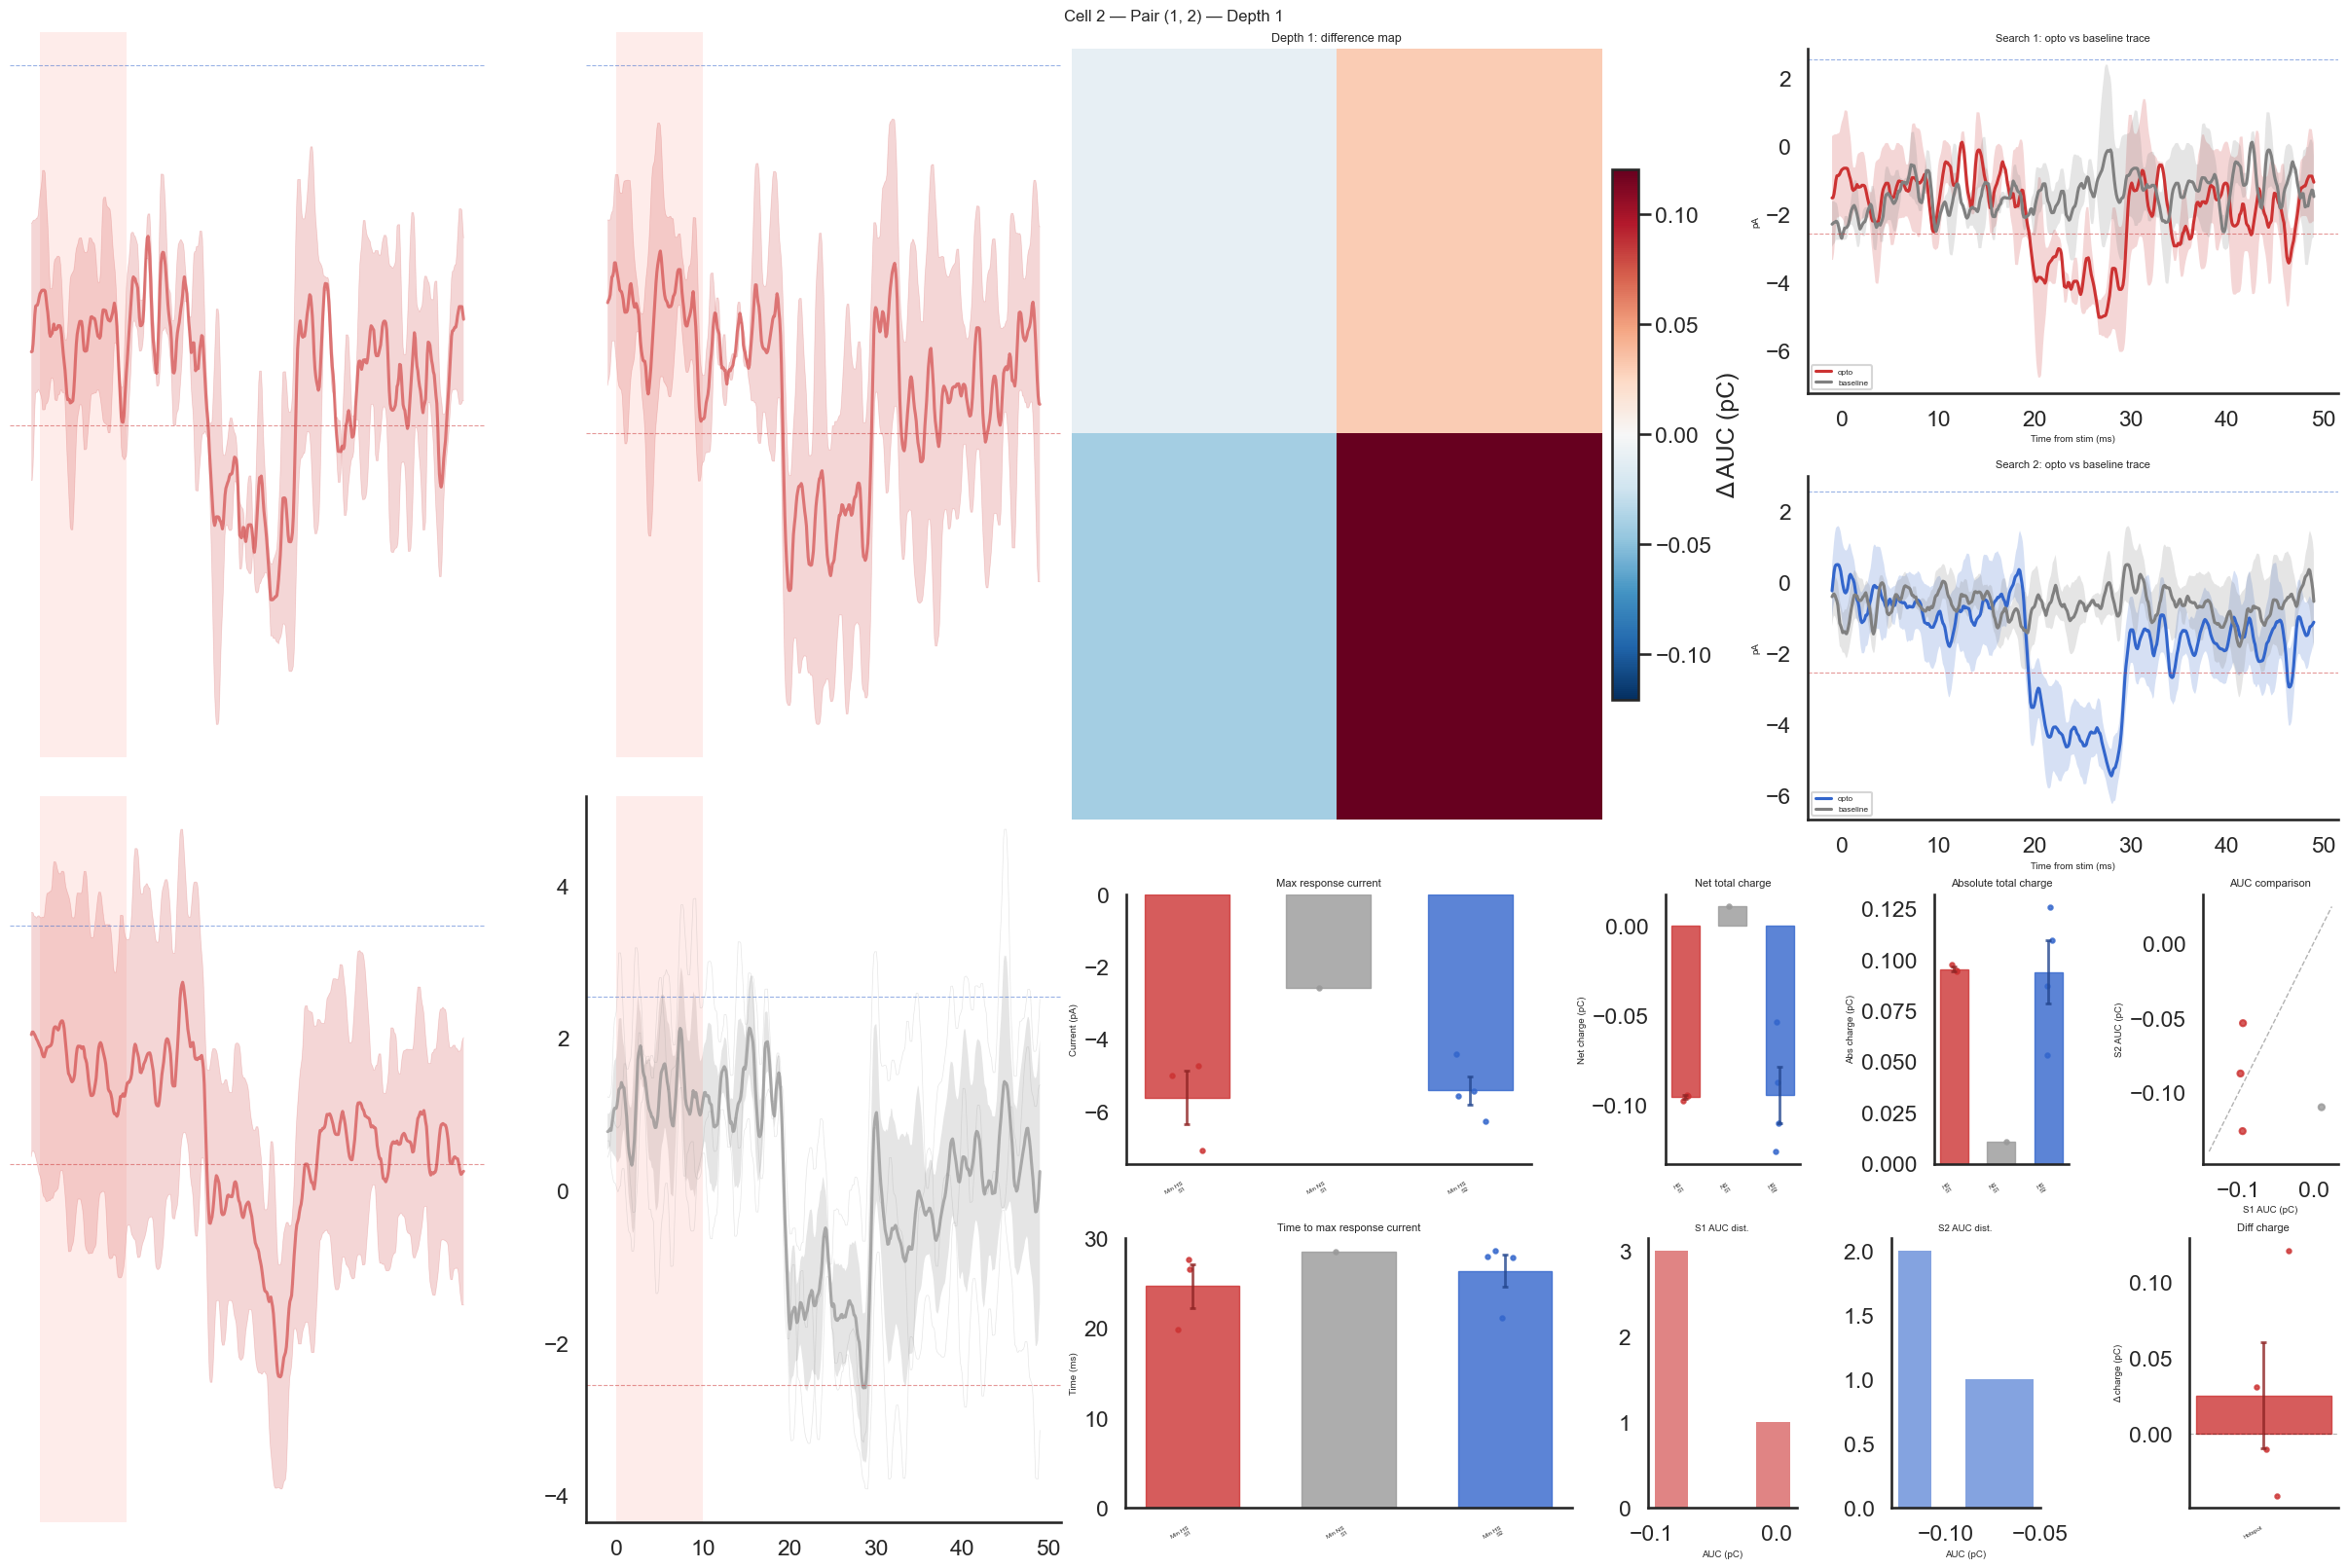

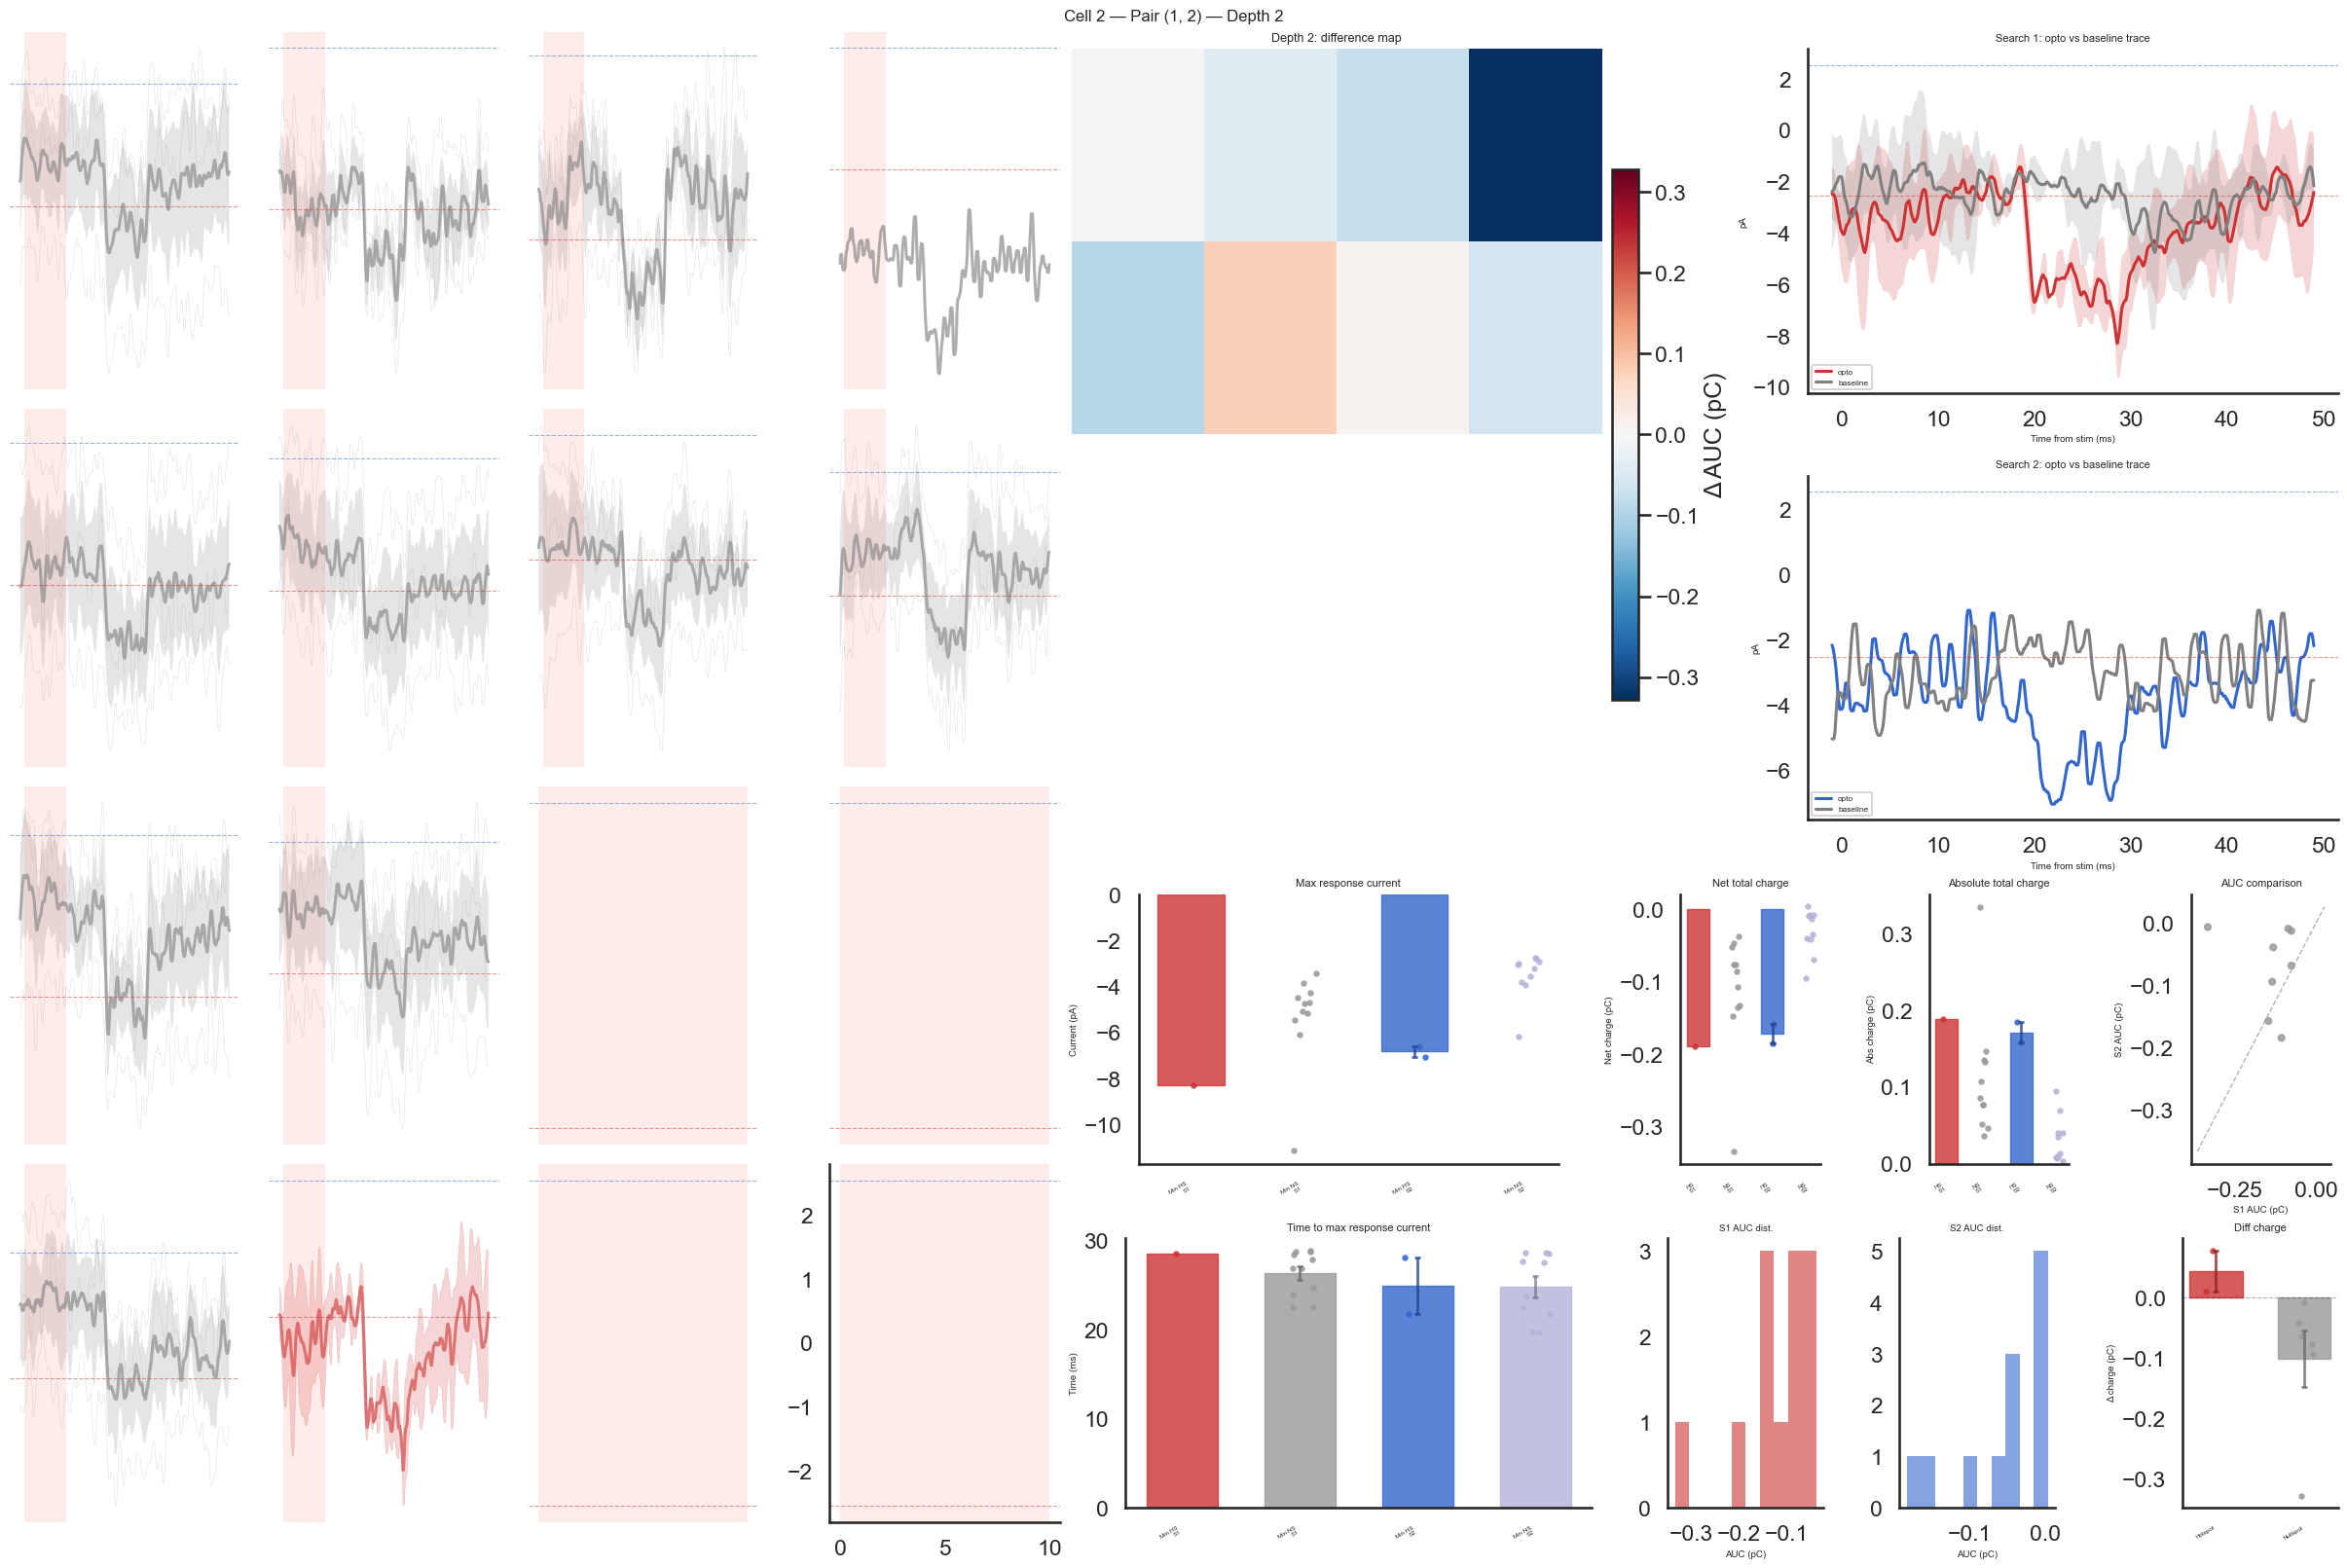

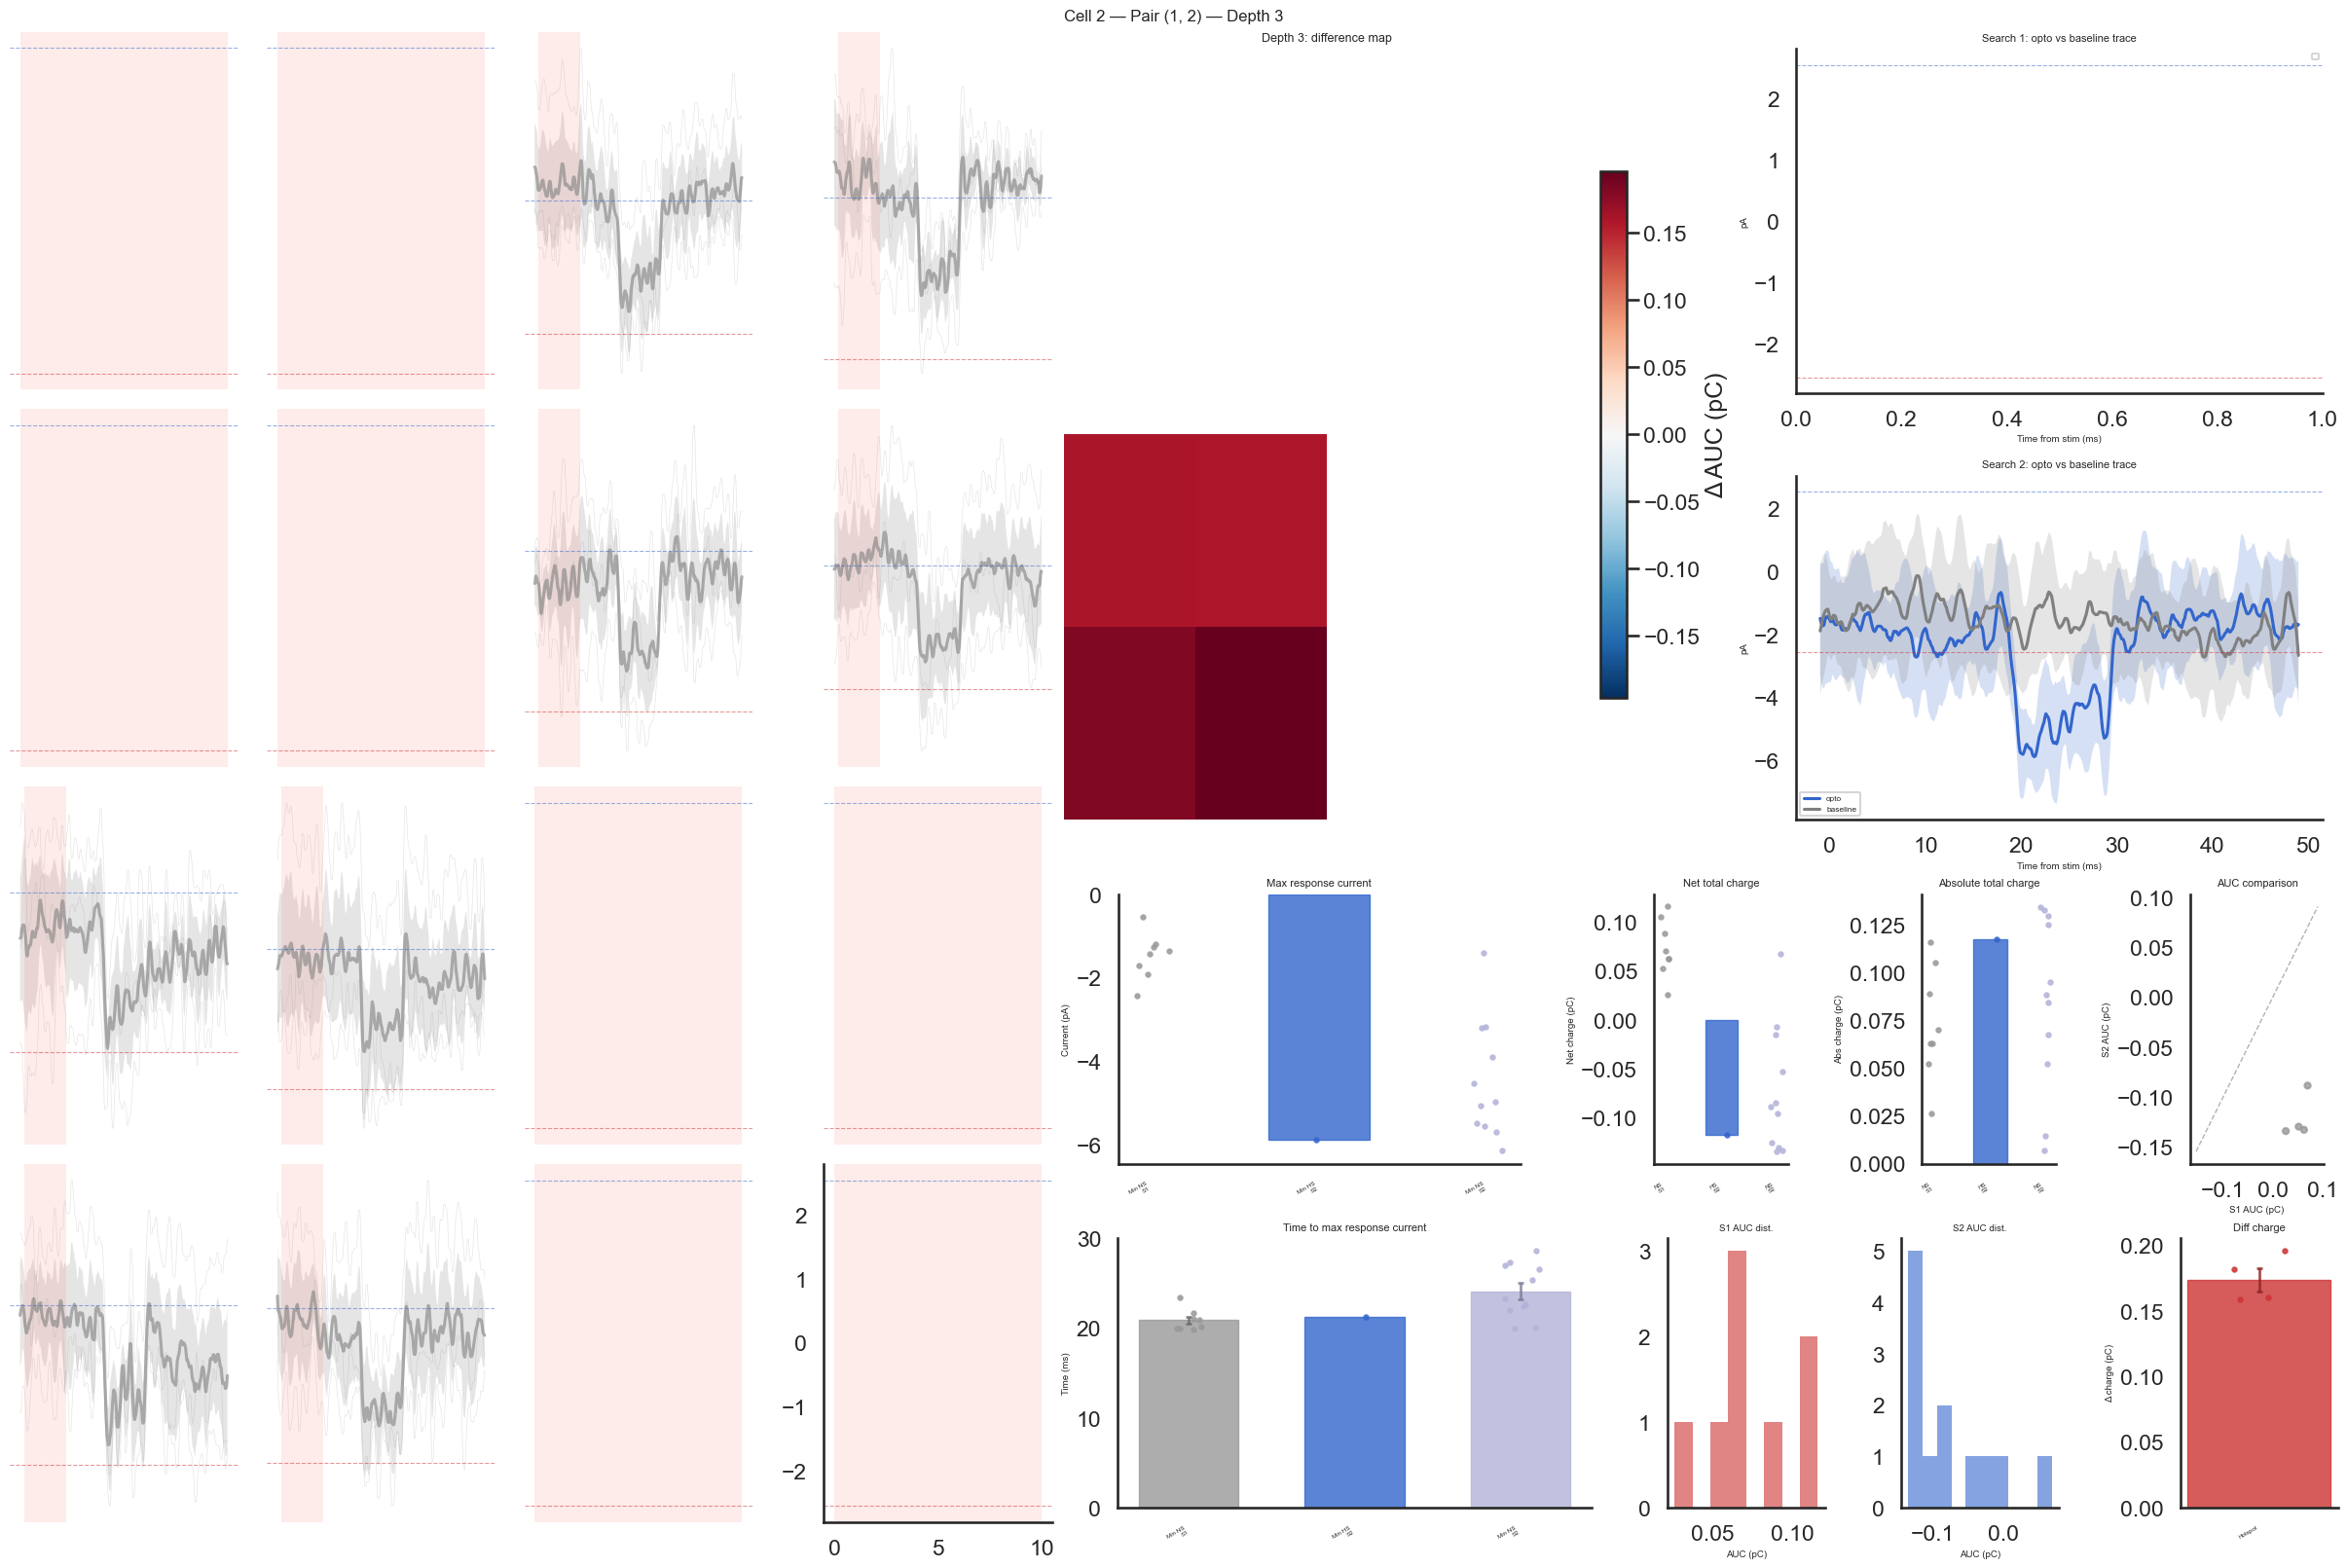

In [11]:
pair_result = ndap.analyze_dmd_search_pair(
    cells_df,
    cell=2,
    pair_idx=0,
    make_plots=True,
    save_dir=SAVE_DIR,
)

print(f"Common depths compared: {len(pair_result['depth_results'])}")
for dr in pair_result["depth_results"]:
    print(f"  depth {dr['depth']}: opto1={dr['opto1'].shape}, opto2={dr['opto2'].shape}")

In [12]:
# Per-depth AUC difference summary
pair_metrics = pair_result["metrics_df"]
pair_metrics.groupby("depth")[["auc_search1", "auc_search2", "auc_diff"]].mean().round(4)

,auc_search1,auc_search2,auc_diff
depth,,,
1,-0.0688,-0.0940,0.0252
2,-0.0887,-0.0409,-0.0478
3,0.0365,-0.0570,0.0935


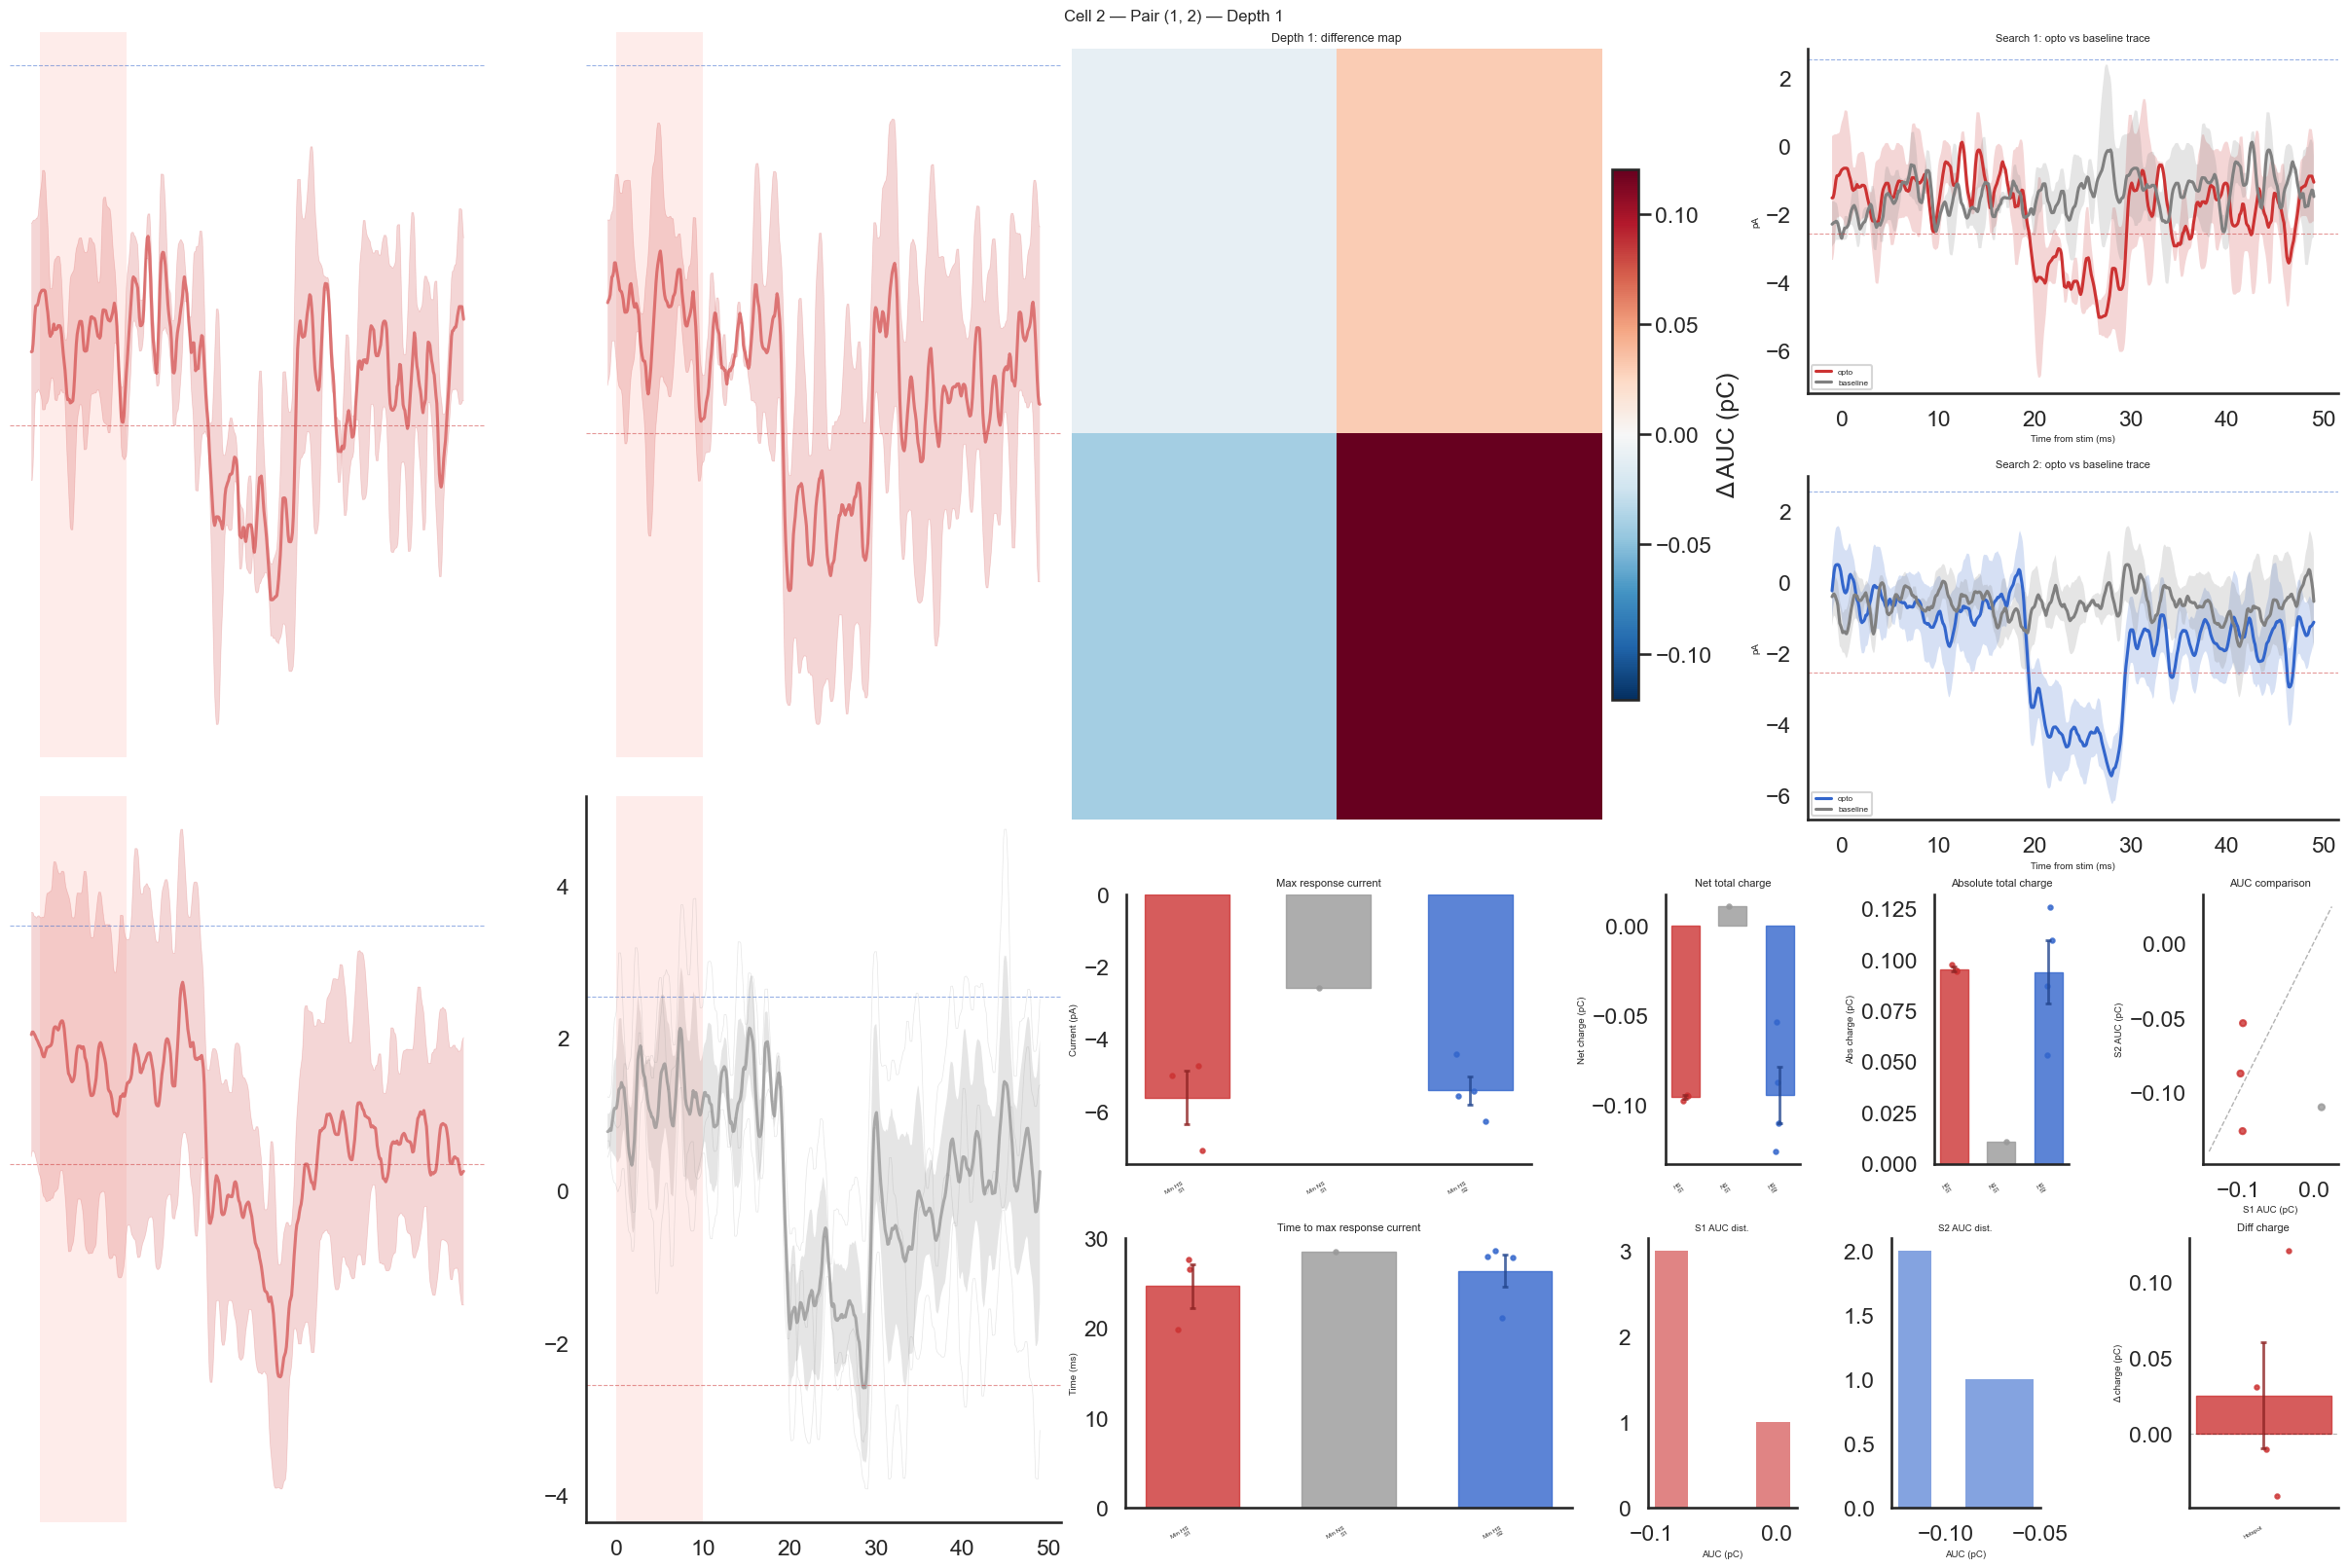

In [13]:
# Display depth-1 pair comparison figure
pair_result["figures"][0]

In [14]:
plt.close("all")
print(f"Done — figures saved to:\n  {SAVE_DIR}")

Done — figures saved to:
  /Volumes/Neurobio/MICROSCOPE/Shun/Project valence/Patch/from_DC_PLOM/SL406/Results-20260109/python_output
